# Práctica grupal - Grupo E

## Autores
- Maria del Mar Beiras Neira
- Huipeng Qu
- Alicia Sambade Mata
- Alejandro Victorero Domínguez

## 1. Contextualización del problema y descripción del dataset

La seguridad vial es uno de los problemas de salud pública más importantes a nivel mundial. Los accidentes de tráfico representan una causa significativa de mortalidad, lesiones y pérdidas económicas. Por lo tanto, comprender los factores que determinan la severidad de un accidente es una cuestión de gran utilidad práctica: permite a las administraciones locales identificar zonas de riesgo, orientar campañas de prevención y mejorar la asignación de recursos de emergencia.

Es por ello que hemos seleccionado para este trabajo el dataset [Cincinatti Car Crashes](https://www.kaggle.com/datasets/steverusso/cincinnati-car-crash-data), el cual recoge todos los accidentes de tráfico reportados en la ciudad de Cincinnati (Estados Unidos) desde el año 2010, y es mantenido públicamente por el Departamento de Policía de Cincinnati (CPD). El dataset original se puede consultar en este [enlace](https://data.cincinnati-oh.gov/safety/Traffic-Crash-Reports-CPD-/rvmt-pkmq/about_data) e incluye accidentes con resultado fatal, con heridos y sin heridos (solo daños materiales), otros datos relativos a las circunstancias del accidente, las condiciones del entorno, las caracteristicas de los implicados y la severidad del siniestro. No obstante, en cumplimiento de la legislación de privacidad vigente, todos los datos han sido anonimizados: las direcciones están agregadas a nivel de bloque y no se incluye ningún identificador personal.

A continuación se indica la definición de cada variable disponible:

![image](Data-Dictionary.png)


En este proyecto, la variable objetivo con la que se va a trabajar es `CRASHSEVERITY`, que clasifica cada accidente según su nivel de gravedad, desde daños materiales únicamente hasta accidente mortal.

## 2. Objetivo principal

El principal objetivo de este trabajo es desarrollar y comparar modelos de Machine Learning capaces de **predecir la severidad de un accidente de tráfico a partir de las condiciones disponibles** en el momento del siniestro o inmediatamente después de él.

## 3. Descarga del dataset

In [5]:
# # Instalar dependencias descomentando estas líneas o manualmente desde la terminal
!pip install kagglehub
!pip install rich
!pip install pandas


In [6]:
import os
import kagglehub
from rich import print
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# fiijando semilla aleatoria para este trabajo
SEED=1234


Puesto que el dataset de Kaggle no es de libre acceso, sino que al menos hay que tener una cuenta en la plataforma para poder descargarlo, se debe configurar a continuación las variables `KAGGLE_USERNAME` y `KAGGLE_KEY`. Se deben sustituir los valores que se indican por defecto a continuación por los propios: nombre de usuario y token de la API, respectivamente.

In [7]:
# configuracion de API de Kaggle
os.environ["KAGGLE_USERNAME"] = "mariadelmarbeiras"
os.environ["KAGGLE_KEY"] = "KGAT_9bb2e421c6672e61c1735a4ef1a3c194"

In [8]:
# Descarga del dataset
path = kagglehub.dataset_download("steverusso/cincinnati-car-crash-data")
print("Path to dataset files:", path)

print("Descargando el dataset")
dataset = pd.read_csv(path+"/cincinnati_traffic_crash_data__cpd.csv") # Carga datos desde un CSV y devuelve un DataFrame
# dataset.to_csv("archivo.csv", index=False)

dataset.head()

Path to dataset files: /home/marimar492/.cache/kagglehub/datasets/steverusso/cincinnati-car-crash-data/versions/1

Descargando el dataset

,Unnamed: 0,ADDRESS_X,LATITUDE_X,LONGITUDE_X,AGE,COMMUNITY_COUNCIL_NEIGHBORHOOD,CPD_NEIGHBORHOOD,CRASHDATE,CRASHLOCATION,CRASHSEVERITY,...,LOCALREPORTNO,MANNEROFCRASH,ROADCONDITIONSPRIMARY,ROADCONTOUR,ROADSURFACE,SNA_NEIGHBORHOOD,TYPEOFPERSON,WEATHER,ZIP,UNITTYPE
0,19,63XX GRACELY,39.107808,-84.688195,31-40,SAYLER PARK,SAYLER PARK,06/17/2014 05:25:00 PM,03 - T-INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),...,145004877,2 - REAR-END,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",SAYLER PARK,D - DRIVER,1 - CLEAR,45233.0,03 - MID SIZE
1,20,9XX CHATEAU AV,39.108110,-84.560280,18-25,EAST PRICE HILL,EAST PRICE HILL,02/15/2015 03:00:00 PM,01 - NOT AN INTERSECTION,2 - INJURY,...,155002081,1 - NOT COLLISION BETWEEN TWO MOTOR VEHICLES I...,01 - DRY,2 - STRAIGHT GRADE,"2 - BLACKTOP, BITUMINOUS, ASPHALT",EAST PRICE HILL,O - OCCUPANT,1 - CLEAR,45204.0,02 - COMPACT
2,21,30XX READING RD,39.135486,-84.496520,18-25,AVONDALE,AVONDALE,07/23/2015 11:54:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),...,155010090,"7 - SIDESWIPE, SAME DIRECTION",01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",AVONDALE,O - OCCUPANT,1 - CLEAR,45206.0,04 - FULL SIZE
3,22,36XX READING RD,39.147889,-84.489222,61-70,AVONDALE,AVONDALE,04/21/2018 01:00:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),...,185005525,"7 - SIDESWIPE, SAME DIRECTION",01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",AVONDALE,D - DRIVER,1 - CLEAR,45229.0,07 - PICKUP
4,23,37XX WARSAW AV,39.110989,-84.573138,31-40,EAST PRICE HILL,EAST PRICE HILL,09/01/2018 07:59:00 PM,03 - T-INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),...,185012267,6 - ANGLE,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",EAST PRICE HILL,D - DRIVER,1 - CLEAR,45205.0,04 - FULL SIZE


In [9]:
# Exploracion de datos

print("Info")
print(dataset.info())
print("Valores nulos")
print(dataset.isnull().sum())

Info

<class 'pandas.DataFrame'>
RangeIndex: 258672 entries, 0 to 258671
Data columns (total 27 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Unnamed: 0                      258672 non-null  int64  
 1   ADDRESS_X                       258669 non-null  str    
 2   LATITUDE_X                      258672 non-null  float64
 3   LONGITUDE_X                     258672 non-null  float64
 4   AGE                             258672 non-null  str    
 5   COMMUNITY_COUNCIL_NEIGHBORHOOD  253006 non-null  str    
 6   CPD_NEIGHBORHOOD                252959 non-null  str    
 7   CRASHDATE                       258669 non-null  str    
 8   CRASHLOCATION                   194021 non-null  str    
 9   CRASHSEVERITY                   258672 non-null  str    
 10  CRASHSEVERITYID                 258672 non-null  float64
 11  DATECRASHREPORTED               258670 non-null  str    
 12  DAYOFWEEK                  

None

Valores nulos

Unnamed: 0                            0
ADDRESS_X                             3
LATITUDE_X                            0
LONGITUDE_X                           0
AGE                                   0
COMMUNITY_COUNCIL_NEIGHBORHOOD     5666
CPD_NEIGHBORHOOD                   5713
CRASHDATE                             3
CRASHLOCATION                     64651
CRASHSEVERITY                         0
CRASHSEVERITYID                       0
DATECRASHREPORTED                     2
DAYOFWEEK                             1
GENDER                            28989
INJURIES                            222
INSTANCEID                            0
LIGHTCONDITIONSPRIMARY                2
LOCALREPORTNO                         0
MANNEROFCRASH                         1
ROADCONDITIONSPRIMARY                 2
ROADCONTOUR                           2
ROADSURFACE                           2
SNA_NEIGHBORHOOD                   5737
TYPEOFPERSON                        222
WEATHER                               2
ZIP                                6585
UNITTYPE                            222
dtype: int64

## 4. Analítica de datos y limpieza inicial de variables

A partir del dataset original se procede a hacer un breve análisis inicial de las variables disponibles. Se remite al significado de cada una a la imagen del _Data Dictionary_ indicado anteriormente. En vista a esta definición inicial, se puede hacer un filtro y transformación sencilla de las variables para preprocesar el dataset antes de pasar a la **transformación de datos** propiamente.

### 4.1  Variables de ID de registros
- La columna ```Unnamed: 0``` corresponde al número de fila, luego la eliminamos porque no aporta información.
- Las columnas ```INSTANCEID``` y ```LOCALREPORTNO``` se refieren al identificador de una incidencia de accidente y al identificador del informe del accidente, respectivamente. No queremos entrenar sobre valores que se refieran a registros.

Se eliminan estas columnas:

In [10]:
print(f"Tamaño del dataset original: {dataset.shape}")
dataset = dataset.drop(columns=["Unnamed: 0","INSTANCEID", "LOCALREPORTNO"])
print(f"Tamaño del dataset tras eliminar columnas de ID de registros: {dataset.shape}")

Tamaño del dataset original: (258672, 27)

Tamaño del dataset tras eliminar columnas de ID de registros: (258672, 24)

### 4.2  Variables de ubicación redundantes

Las siguientes variables sirven para ubicar geográficamente el lugar del incidente. Todas ellas hacen referencia a la ubicación donde ha ocurrido el accidente, pero lo hacen con distintos niveles de precisión. Es conviene reducir redundancia para quedarse con las que aporten más información.

- ```ADDRESS_X```: dirección del accidente, anonimizada a nivel de bloque.
- ```LATITUDE_X```: coordenada geográfica de latitud.
- ```LONGITUDE_X```: coordenada geográfica de longitud.
- ```CPD_NEIGHBORHOOD```: barrio según la división de la policía (Cincinnati Police Department).
- ```SNA_NEIGHBORHOOD```: barrio estadístico de la ciudad de Cincinnati.
- ```ZIP```: código postal.

ADDRESS_X: 12566 valores únicos

CPD_NEIGHBORHOOD: 53 valores únicos

ZIP: 144 valores únicos

SNA_NEIGHBORHOOD: 50 valores únicos

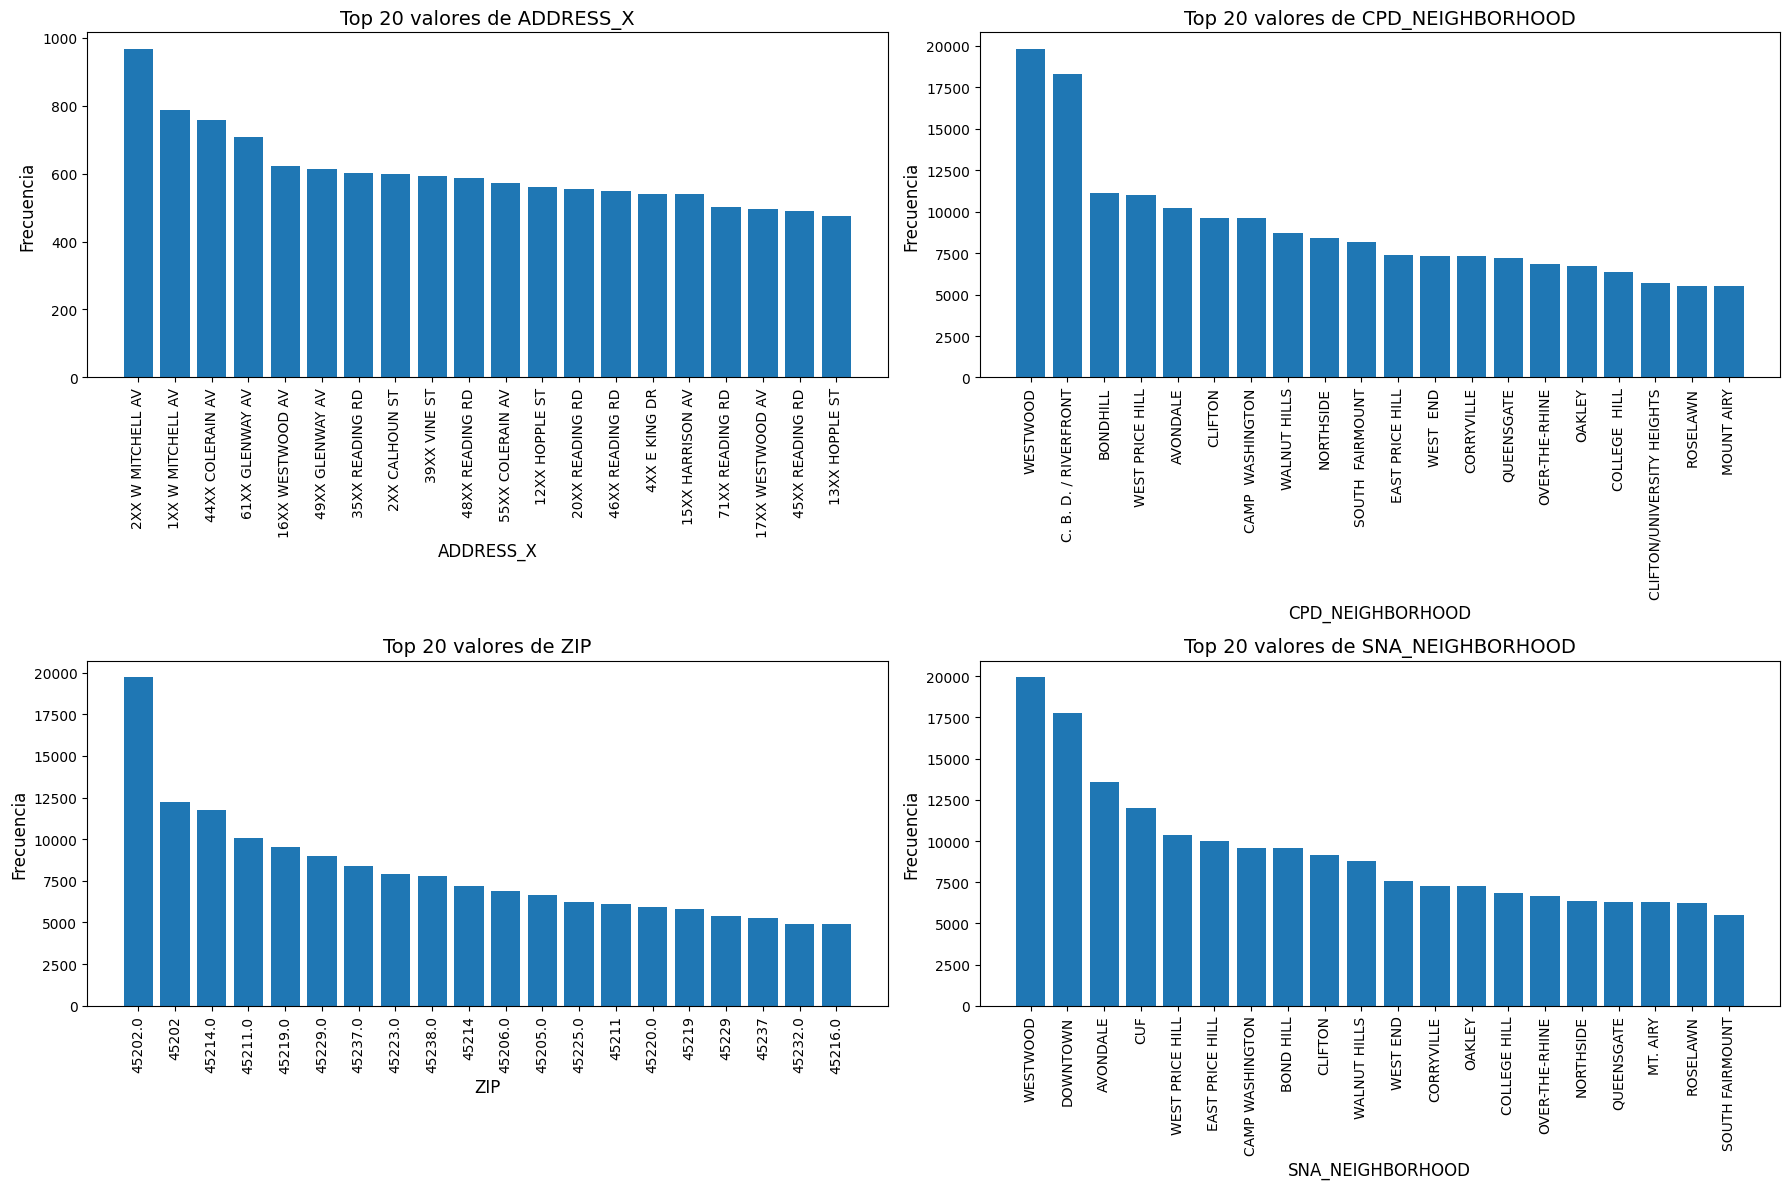

In [11]:
geo_columns = ["ADDRESS_X", "CPD_NEIGHBORHOOD", "ZIP", "SNA_NEIGHBORHOOD"]

# Cantidad de valores únicos
for col in geo_columns:
    print(f"{col}: {dataset[col].nunique()} valores únicos")

# Figura con 2 filas y 2 columnas
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()  # para iterar fácilmente

for i, col in enumerate(geo_columns):
    # Top 20 valores más frecuentes
    top_values = dataset[col].value_counts().head(20)

    axes[i].bar(top_values.index.astype(str), top_values.values)
    axes[i].set_title(f"Top 20 valores de {col}", fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel("Frecuencia", fontsize=12)
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

En primer lugar, se debe descartar la columna ```ADDRESS_X``` ya que sus valores han sido modificados y toma demasiados valores categóricos únicos para que merezca la pena hacer un _encoding_ sobre ellos.

A continuación, parece razonable mantener las coordenadas geográficas ya que son valores de tipo _float_, que podrán ser usados con facilidad en el proceso de entrenamiento.

Finalmente, las variables ```CPD_NEIGHBORHOOD```, ```SNA_NEIGHBORHOOD```, ```COMMUNITY_COUNCIL_NEIGHBORHOOD``` y ```ZIP``` representan agrupaciones dadas ciertas coordenadas geográficas. Puesto que todas ellas representan un tipo de información similar, tomamos inicialmente ```SNA_NEIGHBORHOOD``` para los análisis, aunque podría ser interesante repetir los resultados obtenidos para las otras. Se ha escogido esta principalmente porque la ciudad de Cincinatti ya había hehco una agrupación estadística de los barrios, además de que tiene pocas categorías únicas.

In [12]:
dataset = dataset.drop(columns=["ADDRESS_X","CPD_NEIGHBORHOOD", "COMMUNITY_COUNCIL_NEIGHBORHOOD", "ZIP"])
print(f"Tamaño del dataset tras eliminar columnas de variables de ubicación redundantes: {dataset.shape}")

Tamaño del dataset tras eliminar columnas de variables de ubicación redundantes: (258672, 20)

### 4.3  Variables categóricas idénticas

Se ha observado que las variables ```CRASHSEVERITYID``` y ```CRASHSEVERITY``` representan la misma información, ya que existe una correspondencia uno a uno entre ambas. Se decide eliminar la de ```CRASHSEVERITYID``` porque se empleará la otra para el mapa de valores de severidad que se creará más adelante. Realmente es indiferente cuál de las dos eliminar, pero se conserva ```CRASHSEVERITY``` por ser más clara para esta priemra fase.

In [13]:
# identificar relación uno a uno de los valores
print(dataset.groupby("CRASHSEVERITY")["CRASHSEVERITYID"].unique())
print(dataset.groupby("CRASHSEVERITY")["CRASHSEVERITYID"].nunique())

dataset = dataset.drop(columns=["CRASHSEVERITYID"])
print(f"Tamaño del dataset tras eliminar la columna CRASHSEVERITYID: {dataset.shape}")

CRASHSEVERITY
1 - FATAL                         [201901.0]
1 - FATAL INJURY                       [1.0]
2 - INJURY                             [2.0]
2 - SERIOUS INJURY SUSPECTED      [201902.0]
3 - MINOR INJURY SUSPECTED        [201903.0]
3 - PROPERTY DAMAGE ONLY (PDO)         [3.0]
4 - INJURY POSSIBLE               [201904.0]
5 - PROPERTY DAMAGE ONLY          [201905.0]
Name: CRASHSEVERITYID, dtype: object

CRASHSEVERITY
1 - FATAL                         1
1 - FATAL INJURY                  1
2 - INJURY                        1
2 - SERIOUS INJURY SUSPECTED      1
3 - MINOR INJURY SUSPECTED        1
3 - PROPERTY DAMAGE ONLY (PDO)    1
4 - INJURY POSSIBLE               1
5 - PROPERTY DAMAGE ONLY          1
Name: CRASHSEVERITYID, dtype: int64

Tamaño del dataset tras eliminar la columna CRASHSEVERITYID: (258672, 19)

Tras esta limpieza inicial hemos pasado de 27 variables (columnas) a 20, que, en prinicipio, cuentan con información útil para entrenar los modelos sobre sus instancias.

In [14]:
dataset = dataset.drop_duplicates()
print(f"Tamaño del dataset tras eliminar filas duplicadas: {dataset.shape}")

print("Info actualizada:")
print(dataset.info())
print("Valores nulos actualizado:")
print(dataset.isnull().sum())

dataset.head()

Tamaño del dataset tras eliminar filas duplicadas: (258672, 19)

Info actualizada:

<class 'pandas.DataFrame'>
RangeIndex: 258672 entries, 0 to 258671
Data columns (total 19 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   LATITUDE_X              258672 non-null  float64
 1   LONGITUDE_X             258672 non-null  float64
 2   AGE                     258672 non-null  str    
 3   CRASHDATE               258669 non-null  str    
 4   CRASHLOCATION           194021 non-null  str    
 5   CRASHSEVERITY           258672 non-null  str    
 6   DATECRASHREPORTED       258670 non-null  str    
 7   DAYOFWEEK               258671 non-null  str    
 8   GENDER                  229683 non-null  str    
 9   INJURIES                258450 non-null  str    
 10  LIGHTCONDITIONSPRIMARY  258670 non-null  str    
 11  MANNEROFCRASH           258671 non-null  str    
 12  ROADCONDITIONSPRIMARY   258670 non-null  str    
 13  ROADCONTOUR             258670 non-null  str    
 14  ROADSURFACE             258670 

None

Valores nulos actualizado:

LATITUDE_X                    0
LONGITUDE_X                   0
AGE                           0
CRASHDATE                     3
CRASHLOCATION             64651
CRASHSEVERITY                 0
DATECRASHREPORTED             2
DAYOFWEEK                     1
GENDER                    28989
INJURIES                    222
LIGHTCONDITIONSPRIMARY        2
MANNEROFCRASH                 1
ROADCONDITIONSPRIMARY         2
ROADCONTOUR                   2
ROADSURFACE                   2
SNA_NEIGHBORHOOD           5737
TYPEOFPERSON                222
WEATHER                       2
UNITTYPE                    222
dtype: int64

,LATITUDE_X,LONGITUDE_X,AGE,CRASHDATE,CRASHLOCATION,CRASHSEVERITY,DATECRASHREPORTED,DAYOFWEEK,GENDER,INJURIES,LIGHTCONDITIONSPRIMARY,MANNEROFCRASH,ROADCONDITIONSPRIMARY,ROADCONTOUR,ROADSURFACE,SNA_NEIGHBORHOOD,TYPEOFPERSON,WEATHER,UNITTYPE
0,39.107808,-84.688195,31-40,06/17/2014 05:25:00 PM,03 - T-INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),06/17/2014 05:29:00 PM,TUE,F - FEMALE,1 - NO INJURY / NONE REPORTED,1 - DAYLIGHT,2 - REAR-END,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",SAYLER PARK,D - DRIVER,1 - CLEAR,03 - MID SIZE
1,39.108110,-84.560280,18-25,02/15/2015 03:00:00 PM,01 - NOT AN INTERSECTION,2 - INJURY,02/15/2015 03:10:00 PM,SUN,F - FEMALE,3 - NON-INCAPACITATING,1 - DAYLIGHT,1 - NOT COLLISION BETWEEN TWO MOTOR VEHICLES I...,01 - DRY,2 - STRAIGHT GRADE,"2 - BLACKTOP, BITUMINOUS, ASPHALT",EAST PRICE HILL,O - OCCUPANT,1 - CLEAR,02 - COMPACT
2,39.135486,-84.496520,18-25,07/23/2015 11:54:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),07/23/2015 11:54:00 PM,THU,F - FEMALE,1 - NO INJURY / NONE REPORTED,4 - DARK - LIGHTED ROADWAY,"7 - SIDESWIPE, SAME DIRECTION",01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",AVONDALE,O - OCCUPANT,1 - CLEAR,04 - FULL SIZE
3,39.147889,-84.489222,61-70,04/21/2018 01:00:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),04/21/2018 01:16:00 PM,SAT,M - MALE,1 - NO INJURY / NONE REPORTED,1 - DAYLIGHT,"7 - SIDESWIPE, SAME DIRECTION",01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",AVONDALE,D - DRIVER,1 - CLEAR,07 - PICKUP
4,39.110989,-84.573138,31-40,09/01/2018 07:59:00 PM,03 - T-INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),09/01/2018 07:59:00 PM,SAT,M - MALE,1 - NO INJURY / NONE REPORTED,3 - DUSK,6 - ANGLE,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",EAST PRICE HILL,D - DRIVER,1 - CLEAR,04 - FULL SIZE


## 5. Transformación de los datos

Una vez seleccionadas todas aquellas columnas que, a priori, serán útiles para el análisis, se procede a la trasnformación del tipo de dato para que puedan ser empleados por los diferentes modelos que se desarrollen.

Se observa que hay gran cantidad de columnas con valores nominales, por lo que será necesario valorar el tipo de transformación según el tipo de valores nominales que tomen esas variables, si admiten orden o no.

En primer lugar, las columnas `CRASHDATE` y `DATECRASHREPORTED` se refieren a fechas, por lo que se transforman al tipo de dato de `datetime` para que los modelos puedan aprovechar esta información temporal.

Luego, las siguientes variables son de tipo nominal y sin posibilidad de establecer un orden:
- `CRASHLOCATION`: tipo de vía en la que ocurrió el accidente.
- `MANNEROFCRASH`: forma en la que se produjo la colisión.
- `UNITTYPE`: tipo vehículo implicado en el accidente.
- `GENDER`: género de la persona involucrada en el accidente.
- `SNA_NEIGHBORHOOD`: barrio estadístico de la ciudad de Cincinnati en el que ocurrió el accidente, según la división establecida por el propio municipio.
- `TYPEOFPERSON`: rol de la persona en el accidente.

Se empleará la transformación de _One-Hot Encoding_ para poder trabajar con los valores de estas variables.

Finalmente, las siguientes varibles tienen valores nominales pero admiten un orden.
- `AGE`: rango de edad de la persona involucrada en el accidente.
- `CRASHSEVERITY`: gravedad del accidente.
- `INJURIES`: categoría de las lesiones sufridas por la persona involucrada.
- `LIGHTCONDITIONSPRIMARY`: condiciones de iluminación de la vía en el momento del accidente.
- `ROADSURFACE`: tipo de superficie de la calzada.
- `WEATHER`: condiciones meteorológicas en el momento del accidente.
- `DAYOFWEEK`: día de la semana.
- `ROADCONDITIONSPRIMARY`: estado de la vía.
- `ROADCONTOUR`: geometría de la vía en el punto del accidente.

Se procede con un _Ordinal Encoding_ para poder asignar un valor numérico que respete este orden. Para cada variable, se asignará manualmente un valor de manera ascendente a cada categoría.


In [15]:
# transformar fechas a datetime
dataset["CRASHDATE"] = pd.to_datetime(dataset["CRASHDATE"], format="%m/%d/%Y %I:%M:%S %p")
dataset["DATECRASHREPORTED"] = pd.to_datetime(dataset["DATECRASHREPORTED"], format="%m/%d/%Y %I:%M:%S %p")

In [16]:
numeric_cols = [
    "AGE",
    "CRASHSEVERITY",
    "INJURIES",
    "LIGHTCONDITIONSPRIMARY",
    "ROADSURFACE",
    "WEATHER",
    "DAYOFWEEK",
    "ROADCONDITIONSPRIMARY",
    "ROADCONTOUR"
]

OneHotEncoding_cols = [
    "CRASHLOCATION",
    "MANNEROFCRASH",
    "UNITTYPE",
    "GENDER",
    "SNA_NEIGHBORHOOD",
    "TYPEOFPERSON"
]


# fig, axes = plt.subplots(5, 2, figsize=(20, 15))
# axes = axes.flatten()

# for i, col in enumerate(numeric_cols):
#     dataset[col].value_counts().plot(
#         kind="pie",
#         ax=axes[i],
#         autopct="%1.1f%%"
#     )
#     axes[i].set_title(col)
#     axes[i].set_ylabel("")

# # eliminar subplots vacíos
# for j in range(i+1, len(axes)):
#     fig.delaxes(axes[j])

# plt.suptitle("Distribución CATEGÓRICA", fontsize=16)
# plt.tight_layout()
# plt.show()

# fig, axes = plt.subplots(2, 2, figsize=(20, 15))
# axes = axes.flatten()

# for i, col in enumerate(OneHotEncoding_cols):
#     dataset[col].value_counts().plot(
#         kind="pie",
#         ax=axes[i],
#         autopct="%1.1f%%"
#     )
#     axes[i].set_title(col)
#     axes[i].set_ylabel("")

# # eliminar subplots vacíos
# for j in range(i+1, len(axes)):
#     fig.delaxes(axes[j])

# plt.suptitle("Distribución CATEGÓRICA", fontsize=16)
# plt.tight_layout()
# plt.show()

In [17]:
# variables nominales con orden
AGE_map = {
    'UNDER 18': 0,
    '18-25': 1,
    '26-30': 2,
    '31-40': 3,
    '41-50': 4,
    '51-60': 5,
    '61-70': 6,
    'OVER 70': 7,
    'UNKNOWN': np.nan
}

CRASHSEVERITY_map = {
    '5 - PROPERTY DAMAGE ONLY': 0,
    '3 - PROPERTY DAMAGE ONLY (PDO)': 0,
    '4 - INJURY POSSIBLE': 1,
    '3 - MINOR INJURY SUSPECTED': 2,
    '2 - INJURY': 3,
    '2 - SERIOUS INJURY SUSPECTED': 4,
    '1 - FATAL INJURY': 5,
    '1 - FATAL': 6
}

INJURIES_map = {
    '1 - NO INJURY / NONE REPORTED': 0,
    '5 - NO APPARENTY INJURY': 1,
    '4 - POSSIBLE INJURY': 2,
    '2 - POSSIBLE': 3,
    '3 - NON-INCAPACITATING': 4,
    '3 - SUSPECTED MINOR INJURY': 5,
    '4 - INCAPACITATING': 6,
    '2 - SUSPECTED SERIOUS INJURY': 7,
    '5 - FATAL': 8,
    '1 - FATAL': 8
}

LIGHTCONDITIONSPRIMARY_map = {
    '1 - DAYLIGHT': 0,
    '2 - DAWN': 1,
    '2 - DUSK': 2,
    '3 - DUSK': 2,
    '3 - DARK - LIGHTED ROADWAY': 3,
    '4 - DARK - LIGHTED ROADWAY': 3,
    '4 - DARK – ROADWAY NOT LIGHTED': 4,
    '5 - DARK – ROADWAY NOT LIGHTED': 4,
    '5 - DARK – UNKNOWN ROADWAY LIGHTING': 5,
    '6 - DARK – UNKNOWN ROADWAY LIGHTING': 5,
    '8 - OTHER': np.nan,
    '9 - OTHER': np.nan,
    '9 - UNKNOWN': np.nan
}

ROADSURFACE_map = {
    '1 - CONCRETE': 0,
    '2 - BLACKTOP, BITUMINOUS, ASPHALT': 1,
    '3 - BRICK/BLOCK': 2,
    '4 - SLAG, GRAVEL, STONE': 3,
    '5 - DIRT': 4,
    '6 - OTHER': np.nan,
    '9 - OTHER': np.nan,
    '9 - UNKNOWN': np.nan
}

WEATHER_map = {
    '1 - CLEAR': 0,
    '2 - CLOUDY': 1,
    '3 - FOG, SMOG, SMOKE': 2,
    '4 - RAIN': 3,
    '5 - SLEET, HAIL': 4,
    '5 - SLEET,HAIL': 4,
    '6 - SNOW': 5,
    '7 - SEVERE CROSSWINDS': 6,
    '8 - BLOWING SAND, SOIL, DIRT, SNOW': 7,
    '9 - FREEZING RAIN OR FREEZING DRIZZLE': 8,
    '9 - OTHER/UNKNOWN': np.nan,
    '99 - OTHER/UNKNOWN': np.nan
}

DAYOFWEEK_map = {
    'MON': 0,
    'TUE': 1,
    'WED': 2,
    'THU': 3,
    'FRI': 4,
    'SAT': 5,
    'SUN': 6
}

ROADCONDITIONPRIMARY_map = {
    '01 - DRY': 0,
    '02 - WET': 1,
    '07 - SLUSH': 2,
    '03 - SNOW': 3,
    '04 - ICE': 4,
    '06 - WATER (STANDING, MOVING)': 5,
    '05 - SAND, MUD, DIRT, OIL, GRAVEL': 6,
    '10 - OTHER': np.nan,
    '09 - OTHER': np.nan,
    '09 - UNKNOWN': np.nan,
    '99 - UNKNOWN': np.nan
}

ROADCONTOUR_map = {
    '1 - STRAIGHT LEVEL': 0,
    '2 - STRAIGHT GRADE': 1,
    '3 - CURVE LEVEL': 2,
    '4 - CURVE GRADE': 3,
    '9 - UNKNOWN': np.nan
}

dataset["AGE"] = dataset["AGE"].map(AGE_map)
dataset["CRASHSEVERITY"] = dataset["CRASHSEVERITY"].map(CRASHSEVERITY_map)
dataset["INJURIES"] = dataset["INJURIES"].map(INJURIES_map)
dataset["LIGHTCONDITIONSPRIMARY"] = dataset["LIGHTCONDITIONSPRIMARY"].map(LIGHTCONDITIONSPRIMARY_map)
dataset["ROADSURFACE"] = dataset["ROADSURFACE"].map(ROADSURFACE_map)
dataset["WEATHER"] = dataset["WEATHER"].map(WEATHER_map)
dataset["DAYOFWEEK"] = dataset["DAYOFWEEK"].map(DAYOFWEEK_map)
dataset["ROADCONDITIONSPRIMARY"] = dataset["ROADCONDITIONSPRIMARY"].map(ROADCONDITIONPRIMARY_map)
dataset["ROADCONTOUR"] = dataset["ROADCONTOUR"].map(ROADCONTOUR_map)

In [18]:
# unificar valores de la columna GENDER
dataset["GENDER"] = dataset["GENDER"].replace({
    "MALE": "M - MALE",
    "FEMALE": "F - FEMALE"
})

# sustituir todos los valores de UNKNOWN por NaN
for col in OneHotEncoding_cols:
    dataset[col] = dataset[col].astype(str).str.strip()
    mask = dataset[col].str.contains("unknown", case=False, na=False)
    dataset.loc[mask, col] = np.nan

# aplicar One Hot Encoding a las columnas categóricas que no admiten orden
dataset = pd.get_dummies(dataset, columns=OneHotEncoding_cols, dummy_na=True)

In [19]:
# Info dataset tras el procesado de variables categóricas
print("\nValores nulos (NaN) en columnas categoricas:")
print(dataset[numeric_cols].isna().sum())

print("Info")
print(dataset.info())

print("Columnas del dataset:")
print(list(dataset.columns))

Valores nulos (NaN) en columnas categoricas:

AGE                       31113
CRASHSEVERITY                 0
INJURIES                    222
LIGHTCONDITIONSPRIMARY     2782
ROADSURFACE                 153
WEATHER                    1692
DAYOFWEEK                     1
ROADCONDITIONSPRIMARY      1355
ROADCONTOUR                 196
dtype: int64

Info

<class 'pandas.DataFrame'>
RangeIndex: 258672 entries, 0 to 258671
Columns: 145 entries, LATITUDE_X to TYPEOFPERSON_nan
dtypes: bool(132), datetime64[us](2), float64(10), int64(1)
memory usage: 58.2 MB


None

Columnas del dataset:

[
    'LATITUDE_X',
    'LONGITUDE_X',
    'AGE',
    'CRASHDATE',
    'CRASHSEVERITY',
    'DATECRASHREPORTED',
    'DAYOFWEEK',
    'INJURIES',
    'LIGHTCONDITIONSPRIMARY',
    'ROADCONDITIONSPRIMARY',
    'ROADCONTOUR',
    'ROADSURFACE',
    'WEATHER',
    'CRASHLOCATION_01 - NOT AN INTERSECTION',
    'CRASHLOCATION_02 - FOUR-WAY INTERSECTION',
    'CRASHLOCATION_03 - T-INTERSECTION',
    'CRASHLOCATION_04 - Y-INTERSECTION',
    'CRASHLOCATION_05 - TRAFFIC CIRCLE/ROUNDABOUT',
    'CRASHLOCATION_06 - FIVE-POINT, OR MORE',
    'CRASHLOCATION_07 - ON RAMP',
    'CRASHLOCATION_08 - OFF RAMP',
    'CRASHLOCATION_09 - CROSSOVER',
    'CRASHLOCATION_10 - DRIVEWAY/ALLEY ACCESS',
    'CRASHLOCATION_11 - RAILWAY GRADE CROSSING',
    'CRASHLOCATION_12 - SHARED-USE PATHS OR TRAILS',
    'CRASHLOCATION_nan',
    'MANNEROFCRASH_1 - NOT COLLISION BETWEEN TWO MOTOR VEHICLES IN TRANSPORT',
    'MANNEROFCRASH_2 - REAR-END',
    'MANNEROFCRASH_3 - HEAD-ON',
    'MANNEROFCRASH_4 - REAR-TO-REAR',
    'MANNEROFCRASH_5 - BACKING',
    'MANNEROFCRASH_6 - ANGLE',
    'MANNEROFCRASH_7 - SIDESWIPE, SAME DIRECTION',
    'MANNEROFCRASH_8 - SIDESWIPE, OPPOSITE DIRECTION',
    'MANNEROFCRASH_nan',
    'UNITTYPE_01 - PASSENGER CAR',
    'UNITTYPE_01 - SUB-COMPACT',
    'UNITTYPE_02 - COMPACT',
    'UNITTYPE_02 - PASSENGER VAN (MINIVAN)',
    'UNITTYPE_03 - MID SIZE',
    'UNITTYPE_03 - SPORT UTILITY VEHICLE',
    'UNITTYPE_04 - FULL SIZE',
    'UNITTYPE_04 - PICK UP',
    'UNITTYPE_05 - CARGO VAN',
    'UNITTYPE_05 - MINIVAN',
    'UNITTYPE_06 - SPORT UTILITY VEHICLE',
    'UNITTYPE_06 - VAN (9-15 SEATS)',
    'UNITTYPE_07 - MOTORCYCLE 2 WHEELED',
    'UNITTYPE_07 - PICKUP',
    'UNITTYPE_08 - MOTORCYCLE 3 WHEELED',
    'UNITTYPE_08 - VAN',
    'UNITTYPE_09 - AUTOCYCLE',
    'UNITTYPE_09 - MOTORCYCLE',
    'UNITTYPE_10 - MOPED OR MOTORIZED BICYCLE',
    'UNITTYPE_10 - MOTORIZED BICYCLE',
    'UNITTYPE_11 - ALL TERRAIN VEHICLE (ATV/UTV)',
    'UNITTYPE_11 - SNOWMOBILE/ATV',
    'UNITTYPE_12 - GOLF CART',
    'UNITTYPE_12 - OTHER PASSENGER VEHICLE',
    'UNITTYPE_13 - SINGLE UNIT TRUCK OR VAN 2 AXLES, 6 TIRES',
    'UNITTYPE_14 - SINGLE UNIT TRUCK',
    'UNITTYPE_14 - SINGLE UNIT TRUCK; 3+ AXLES',
    'UNITTYPE_15 - SEMI-TRACTOR',
    'UNITTYPE_15 - SINGLE UNIT TRUCK / TRAILER',
    'UNITTYPE_16 - TRUCK/TRACTOR (BOBTAIL)',
    'UNITTYPE_17 - MOTORHOME',
    'UNITTYPE_17 - TRACTOR/SEMI-TRAILER',
    'UNITTYPE_18 - LIMO (LIVERY VEHICLE)',
    'UNITTYPE_18 - TRACTOR/DOUBLES',
    'UNITTYPE_19 - BUS (16+ PASSENGERS)',
    'UNITTYPE_19 - TRACTOR/TRIPLES',
    'UNITTYPE_20 - OTHER MED/HEAVY VEHICLE',
    'UNITTYPE_20 - OTHER VEHICLE',
    'UNITTYPE_21 - BUS /VAN (9-15 SEATS INCLUDING THE DRIVER)',
    'UNITTYPE_21 - HEAVY EQUIPMENT',
    'UNITTYPE_22 - ANIMAL WITH RIDER OR ANIMAL DRAWN VEHICLE',
    'UNITTYPE_22 - BUS (16+ SEATS, INCLUDING THE DRIVER)',
    'UNITTYPE_23 - PEDESTRIAN/SKATER',
    'UNITTYPE_24 - ANIMAL WITH BUGGY, WAGON, SURREY',
    'UNITTYPE_24 - WHEELCHAIR (ANY TYPE)',
    'UNITTYPE_25 - BICYCLE/PEDACYCLIST',
    'UNITTYPE_25 - OTHER NON-MOTORIST',
    'UNITTYPE_26 - BICYCLE',
    'UNITTYPE_26 - PEDESTRIAN/SKATER',
    'UNITTYPE_27 - OTHER NON-MOTORIST',
    'UNITTYPE_27 - TRAIN',
    'UNITTYPE_nan',
    'GENDER_F - FEMALE',
    'GENDER_M - MALE',
    'GENDER_nan',
    'SNA_NEIGHBORHOOD_AVONDALE',
    'SNA_NEIGHBORHOOD_BOND HILL',
    'SNA_NEIGHBORHOOD_CALIFORNIA',
    'SNA_NEIGHBORHOOD_CAMP WASHINGTON',
    'SNA_NEIGHBORHOOD_CARTHAGE',
    'SNA_NEIGHBORHOOD_CLIFTON',
    'SNA_NEIGHBORHOOD_COLLEGE HILL',
    'SNA_NEIGHBORHOOD_COLUMBIA TUSCULUM',
    'SNA_NEIGHBORHOOD_CORRYVILLE',
    'SNA_NEIGHBORHOOD_CUF',
    'SNA_NEIGHBORHOOD_DOWNTOWN',
    'SNA_NEIGHBORHOOD_EAST END',
    'SNA_NEIGHBORHOOD_EAST PRICE HILL',
    'SNA_NEIGHBORHOOD_EAST WALNUT HILLS',
    'SNA_NEIGHBORHOOD_EAST WESTWOOD',
    'SNA_NEIGHBORHOOD_ENGLISH WOODS',
    'SNA_NEIGHBORHOOD_EVANSTON',
    'SNA_NEIGHBORHOOD_HARTWELL',
    'SNA_NEIGHBORHOOD_HYDE PARK',
    'SNA_NEIGHBORH

### 5.1 Data imputation

Como se muestra en la última celda de ejecución, tras el proceso de codificación, el dataset presenta valores ausentes (`NaN`) en varias columnas. La mayor parte de estos valores provienen de dos fuentes principales: los registros que originalmente figuraban como `UNKNOWN` en las variables categóricas, a los que se asignó `NaN` explícitamente durante el _Ordinal Encoding_, y las columnas del _One-Hot Encoding_ para las que se activó la opción `dummy_na=True`, que crea una columna adicional para capturar la ausencia de valor. 

Existen distintas estrategias para tratar estos valores ausentes, pero se ha decidido en esta primera iteración del trabajo **se opta por la eliminación directa de filas como aproximación inicial**, dado que el dataset cuenta con un volumen de registros suficientemente grande como para asumir esta pérdida sin comprometer la capacidad de entrenamiento. Esta decisión se revisará si los resultados de los modelos se ven afectados de forma significativa, en especial en las clases de mayor severidad, que son las menos frecuentes y, por lo tanto, las más sensibles a la reducción de instancias.

In [20]:
# eliminar nan (naive)
previous_shape = dataset.shape[0]
print("Tamaño antes de eliminar NaN:", previous_shape)
dataset = dataset.dropna()
new_shape = dataset.shape[0]
print("Tamaño después de eliminar NaN:", new_shape)
print("Filas eliminadas:", previous_shape - new_shape)

Tamaño antes de eliminar NaN: 258672

Tamaño después de eliminar NaN: 225735

Filas eliminadas: 32937

### 5.2 División de los datos

Para poder entrenar, optimizar y evaluar los modelos de manera adecuada, el dataset se divide en los tres conjuntos disjuntos habituales: **entrenamiento** (70%), **test** (20%) y **validación** (10%). La opción `shuffle=True` con una semilla fija garantizan que la mezcla de datos sea aleatoria y los resultados sean reproducibles.

In [21]:
# 70% trainset, 20% testset, 10% validationset
trainset, testset = train_test_split(dataset, test_size=0.3, train_size=0.7, random_state=SEED, shuffle=True)
testset, validationset = train_test_split(testset, test_size=2/3, train_size=1/3, random_state=SEED, shuffle=True)

## 6. Modelo 1: Random Forest

En este bloque se importan las librerías necesarias para el modelado:

- **`RandomForestClassifier`**: el clasificador de Random Forest de scikit-learn.
- **`GridSearchCV`**, **`cross_val_score`** y **`KFold`**: para la búsqueda de hiperparámetros y la validación cruzada.
- **Métricas**: `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix` y `classification_report` para evaluar los resultados.
- **`seaborn`**: para visualizar la matriz de confusión con un mapa de calor.

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


### 6.1. Preparación de los conjuntos de datos para el modelo

Antes de entrenar, hay que separar las variables de entrada (X) de la variable a predecir (y) en cada uno de los tres conjuntos.

La variable objetivo es `CRASHSEVERITY`. Las columnas `CRASHDATE` y `DATECRASHREPORTED` no se pueden usar directamente en formato datetime, pero antes de descartarlas se extraen dos características temporales: la **hora del accidente** (`CRASH_HOUR`) y el **mes** (`CRASH_MONTH`). La hora puede capturar diferencias entre hora punta y madrugada, y el mes recoge variaciones estacionales en las condiciones de conducción (hielo en invierno, más tráfico en verano). `DATECRASHREPORTED` se descarta porque la única información útil sería la diferencia respecto a `CRASHDATE`, lo que se deja como posible mejora futura.

También hay que asegurarse de que el conjunto de validación no se usa en ningún momento durante el entrenamiento ni la optimización, para que sus métricas reflejen el rendimiento real sobre datos completamente nuevos.

In [23]:
# Ingeniería de variables: extraer hora y mes de CRASHDATE antes de descartarla
def add_time_features(df):
    d = df.copy()
    d['CRASH_HOUR'] = d['CRASHDATE'].dt.hour
    d['CRASH_MONTH'] = d['CRASHDATE'].dt.month
    return d

trainset = add_time_features(trainset)
testset = add_time_features(testset)
validationset = add_time_features(validationset)

# Definir variable objetivo
target_column = 'CRASHSEVERITY'

if target_column not in trainset.columns:
    print(f"Columna '{target_column}' no encontrada")
    print(f"Columnas disponibles: {trainset.columns.tolist()}")
else:
    # Separar features y target en cada set
    y_train = trainset[target_column]
    X_train = trainset.drop(columns=[target_column, "CRASHDATE", "DATECRASHREPORTED"])

    y_test = testset[target_column]
    X_test = testset.drop(columns=[target_column, "CRASHDATE", "DATECRASHREPORTED"])

    y_val = validationset[target_column]
    X_val = validationset.drop(columns=[target_column, "CRASHDATE", "DATECRASHREPORTED"])

    print(f"Conjunto de Entrenamiento (Train): {X_train.shape[0]} muestras, {X_train.shape[1]} features")
    print(f"Conjunto de Test: {X_test.shape[0]} muestras, {X_test.shape[1]} features")
    print(f"Conjunto de Validación: {X_val.shape[0]} muestras, {X_val.shape[1]} features")

    print("--- Distribución de clases en Train ---")
    print(y_train.value_counts().sort_index())
    print("Proporción:")
    print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))


Conjunto de Entrenamiento (Train): 158014 muestras, 144 features

Conjunto de Test: 22573 muestras, 144 features

Conjunto de Validación: 45148 muestras, 144 features

--- Distribución de clases en Train ---

CRASHSEVERITY
0    113443
1      5038
2      6174
3     32282
4       690
5       263
6       124
Name: count, dtype: int64

Proporción:

CRASHSEVERITY
0    71.79
1     3.19
2     3.91
3    20.43
4     0.44
5     0.17
6     0.08
Name: proportion, dtype: float64

El primer modelo que se va a entrenar es un **Random Forest**. Se ha elegido este algoritmo por varias razones prácticas para este problema:

- No requiere normalizar los datos. Los modelos basados en árboles toman decisiones por umbrales de valor, por lo que la escala de las variables no afecta al resultado. Esto simplifica el pipeline dado que el dataset contiene variables de tipos muy distintos (ordinales, binarias del one-hot encoding, coordenadas...).
- Al combinar múltiples árboles entrenados sobre subconjuntos aleatorios, es resistente al sobreajuste.
- Genera directamente la importancia de cada variable, lo que ayuda a entender qué factores influyen más en la severidad del accidente.

El proceso se divide en tres pasos: entrenar un modelo inicial con parámetros por defecto (*baseline*), evaluar su estabilidad con validación cruzada y, por último, buscar una mejor configuración con GridSearchCV.

### 6.2. Modelo Baseline (sin optimización de hiperparámetros)

Lo primero es entrenar el modelo con los parámetros por defecto, sin ningún ajuste. Esto sirve como referencia para saber si el algoritmo ya funciona razonablemente bien con este dataset y para cuantificar después cuánto mejora la optimización.

In [24]:
import time

# Crear modelo baseline
model_forest_baseline = RandomForestClassifier(
    random_state=SEED,
    n_jobs=-1
)

# Entrenar
print("Entrenando modelo baseline...")
start_time = time.time()
model_forest_baseline.fit(X_train, y_train)
elapsed = time.time() - start_time
print(f"Entrenamiento completado en {elapsed:.2f} segundos")

# Predicciones
y_pred_baseline_train = model_forest_baseline.predict(X_train)
y_pred_baseline_test = model_forest_baseline.predict(X_test)
y_pred_baseline_val = model_forest_baseline.predict(X_val)

# Evaluación
print("--- Resultados BASELINE ---")
acc_baseline_train = accuracy_score(y_train, y_pred_baseline_train)
acc_baseline_test = accuracy_score(y_test, y_pred_baseline_test)
acc_baseline_val = accuracy_score(y_val, y_pred_baseline_val)

print(f"Train Accuracy: {acc_baseline_train:.4f}")
print(f"Test Accuracy:  {acc_baseline_test:.4f}")
print(f"Val Accuracy:   {acc_baseline_val:.4f}")

# Visualizar gap overfitting
gap = acc_baseline_train - acc_baseline_test
print(f"Gap Train-Test: {gap:.4f}", end="")
if gap > 0.15:
    print("(Overfitting moderado)")
elif gap > 0.05:
    print(" ✓ (Normal para Random Forest)")
else:
    print(" ✓ (Bajo overfitting)")

Entrenando modelo baseline...

Entrenamiento completado en 42.45 segundos

--- Resultados BASELINE ---

Train Accuracy: 1.0000

Test Accuracy:  0.8871

Val Accuracy:   0.8892

Gap Train-Test: 0.1129

✓ (Normal para Random Forest)

### 6.3. Validación cruzada con K-Fold (5 pliegues)

Para comprobar que el rendimiento del baseline no depende de cómo se hayan dividido los datos, se aplica validación cruzada con 5 pliegues. La idea es dividir el conjunto de entrenamiento en 5 partes, entrenar el modelo 5 veces usando cada vez una parte distinta como validación interna, y promediar los resultados.

Si los scores de los 5 folds son similares entre sí, el modelo es consistente. Si hay mucha variabilidad, significaría que el rendimiento depende demasiado de la partición concreta.

Se usa `KFold` con shuffle activado y semilla fija para que los resultados sean reproducibles.

Ejecutando validación cruzada con 5 folds...

Scores de cada fold:

Fold 1: 0.8871 [████████████████████████████████████████████░░░░░░]

Fold 2: 0.8862 [████████████████████████████████████████████░░░░░░]

Fold 3: 0.8878 [████████████████████████████████████████████░░░░░░]

Fold 4: 0.8821 [████████████████████████████████████████████░░░░░░]

Fold 5: 0.8844 [████████████████████████████████████████████░░░░░░]

Media CV Accuracy: 0.8855 (+/- 0.0021)

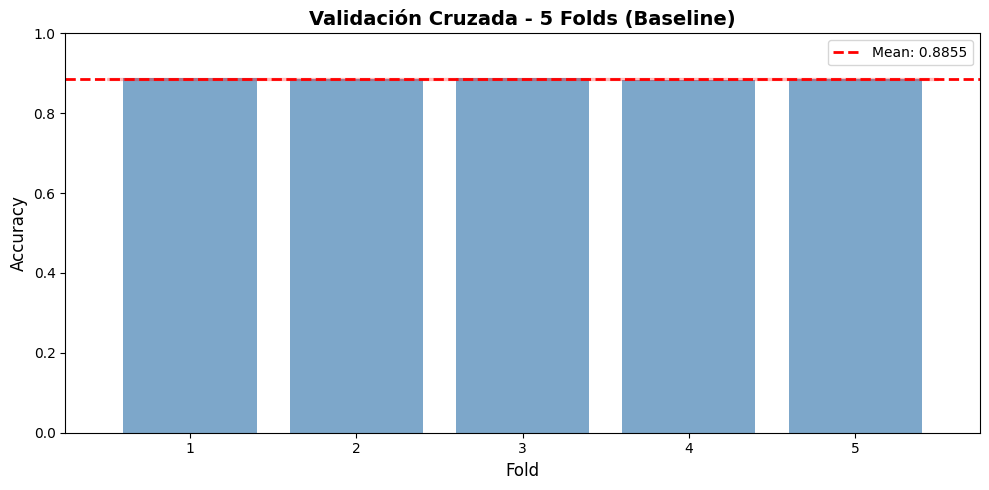

In [25]:
# Configurar KFold
kfold = KFold(n_splits=5, shuffle=True, random_state=SEED)

# Realizar cross-validation
print("Ejecutando validación cruzada con 5 folds...")
cv_scores = cross_val_score(
    model_forest_baseline,
    X_train,
    y_train,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1
)

print("Scores de cada fold:")
for i, score in enumerate(cv_scores, 1):
    bar = "█" * int(score * 50) + "░" * (50 - int(score * 50))
    print(f"  Fold {i}: {score:.4f} [{bar}]")

print(f"Media CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Visualizar CV scores
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(cv_scores) + 1), cv_scores, color='steelblue', alpha=0.7)
ax.axhline(y=cv_scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {cv_scores.mean():.4f}')
ax.fill_between(np.arange(0.5, len(cv_scores) + 0.5 + 0.01, 0.01),
                cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(),
                alpha=0.2, color='red')
ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Validación Cruzada - 5 Folds (Baseline)', fontweight='bold', fontsize=14)
ax.set_ylim([0, 1])
ax.legend()
plt.tight_layout()
plt.show()

### 6.4. Optimización de hiperparámetros con GridSearchCV

Visto el rendimiento del baseline, el siguiente paso es buscar una mejor configuración de hiperparámetros. Para ello se usa `GridSearchCV`, que prueba todas las combinaciones posibles de los valores definidos y selecciona la mejor según validación cruzada interna de 5 pliegues.

Los hiperparámetros explorados son:

| Hiperparámetro | Valores probados | Descripción |
|---|---|---|
| `n_estimators` | [100] | Número de árboles en el bosque |
| `max_depth` | [15, 25] | Profundidad máxima de cada árbol para controlar el sobreajuste |
| `min_samples_split` | [5] | Mínimo de muestras para dividir un nodo interno |
| `min_samples_leaf` | [2] | Mínimo de muestras en una hoja terminal |
| `max_features` | ['sqrt'] | Features a considerar en cada división |
| `class_weight` | ['balanced'] | Pondera las clases para compensar el desbalance |

La cuadrícula se ha mantenido reducida para no disparar el tiempo de cómputo. Se incluye `class_weight='balanced'` porque las clases de `CRASHSEVERITY` están muy desbalanceadas (la mayoría son accidentes sin heridos), y sin este ajuste el modelo tendería a ignorar las clases minoritarias.

Como métrica de optimización se usa **F1-Weighted** en lugar de accuracy porque, con clases tan desbalanceadas, la accuracy puede ser engañosa: un modelo que prediga siempre la clase mayoritaria puede tener un accuracy alto pero ser inútil para detectar los accidentes más graves.

In [26]:
import time

# Grid reducido para no disparar el tiempo de computo
param_grid_fast = {
    'n_estimators': [100],              # Solo 1 valor
    'max_depth': [15, 25],              # Solo 2 valores
    'min_samples_split': [5],           # Solo 1 valor
    'min_samples_leaf': [2],            # Solo 1 valor
    'max_features': ['sqrt'],           # Solo 1 valor
    'class_weight': ['balanced']        # Solo 1 valor
}

# Calcular total de combinaciones
total_combinations = 1
for values in param_grid_fast.values():
    total_combinations *= len(values)

print(f"Parámetros a probar (GRID REDUCIDO):")
for param, values in param_grid_fast.items():
    print(f"  - {param}: {values}")

print(f"Total de combinaciones: {total_combinations}")
print(f"Total de entrenamientos (5-fold CV): {total_combinations * 5}")

start_time = time.time()

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_grid=param_grid_fast,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1  # Reducido a 1 para menos output
)

grid_search.fit(X_train, y_train)

elapsed_time = time.time() - start_time

print(f"GridSearchCV completado en {elapsed_time:.2f} segundos ({elapsed_time/60:.2f} minutos)")

print("Mejores parametros:")
for param, value in grid_search.best_params_.items():
    print(f"  - {param}: {value}")

print(f"Mejor score CV F1-Weighted: {grid_search.best_score_:.4f}")

Parámetros a probar (GRID REDUCIDO):

- n_estimators: [100]

- max_depth: [15, 25]

- min_samples_split: [5]

- min_samples_leaf: [2]

...

- max_features: sqrt

- min_samples_leaf: 2

- min_samples_split: 5

- n_estimators: 100

Mejor score CV F1-Weighted: 0.8093

### 6.5. Evaluación del modelo optimizado

Una vez que GridSearchCV ha encontrado la mejor combinación de hiperparámetros, se recupera el modelo ya entrenado con esa configuración (`best_estimator_`) y se evalúa sobre los tres conjuntos.

Comparar train, test y validación permite detectar sobreajuste: si el train está muy por encima del test, el modelo ha memorizado los datos en lugar de aprender patrones generales.

Se calculan accuracy, precision, recall y F1-Score en su variante `weighted` para tener en cuenta el desbalance de clases. También se imprime el `classification_report` completo para ver cómo se comporta el modelo en cada nivel de severidad por separado, ya que puede haber diferencias importantes entre clases frecuentes (daños materiales) y clases raras (accidentes fatales).

In [27]:
# Usar los mejores parámetros
model_forest_best = grid_search.best_estimator_

# Predicciones
y_pred_best_train = model_forest_best.predict(X_train)
y_pred_best_test = model_forest_best.predict(X_test)
y_pred_best_val = model_forest_best.predict(X_val)

# Métricas
acc_best_train = accuracy_score(y_train, y_pred_best_train)
acc_best_test = accuracy_score(y_test, y_pred_best_test)
prec_best_test = precision_score(y_test, y_pred_best_test, average='weighted', zero_division=0)
rec_best_test = recall_score(y_test, y_pred_best_test, average='weighted', zero_division=0)
f1_best_test = f1_score(y_test, y_pred_best_test, average='weighted', zero_division=0)
acc_best_val = accuracy_score(y_val, y_pred_best_val)

print("--- Metricas (test) ---")
print(f"Accuracy:  {acc_best_test:.4f}")
print(f"Precision: {prec_best_test:.4f}")
print(f"Recall:    {rec_best_test:.4f}")
print(f"F1-Score:  {f1_best_test:.4f}")

print("--- Classification report ---")
print(classification_report(y_test, y_pred_best_test, zero_division=0))

print("--- Accuracy train / test / val ---")
print(f"Train: {acc_best_train:.4f}")
print(f"Test:  {acc_best_test:.4f}")
print(f"Val:   {acc_best_val:.4f}")

--- Metricas (test) ---

Accuracy:  0.7839

Precision: 0.8554

Recall:    0.7839

F1-Score:  0.8069

...

precision    recall  f1-score   support

           0       0.89      0.82      0.85     16142
           1       0.23      0.90      0.36       765
           2       0.57      0.70      0.63       866
           3       0.90      0.65      0.76      4640
           4       0.89      0.54      0.67       110
           5       1.00      0.27      0.43        37
           6       0.78      0.54      0.64        13

    accuracy                           0.78     22573
   macro avg       0.75      0.63      0.62     22573
weighted avg       0.86      0.78      0.81     22573

--- Accuracy train / test / val ---

Train: 0.8459

Test:  0.7839

Val:   0.7873

### 6.6. Visualización de resultados

Se generan dos gráficas para interpretar mejor los resultados:

#### Matriz de confusión
Muestra cuántas instancias de cada clase real han sido clasificadas como cada clase predicha. Es útil para ver en qué categorías de severidad falla más el modelo y si hay confusiones sistemáticas entre clases concretas (p.ej. entre accidentes con lesiones posibles y accidentes con daños materiales únicamente).

#### Importancia de características (*Feature Importance*)
Muestra las 15 variables que más influyen en las predicciones. En Random Forest esta importancia se calcula a partir de cuánto reduce la impureza Gini cada variable en promedio a lo largo de todos los árboles. Sirve para comprobar si los factores más relevantes tienen sentido desde el punto de vista de la seguridad vial, e identificar si hay variables que aportan poco y podrían descartarse.

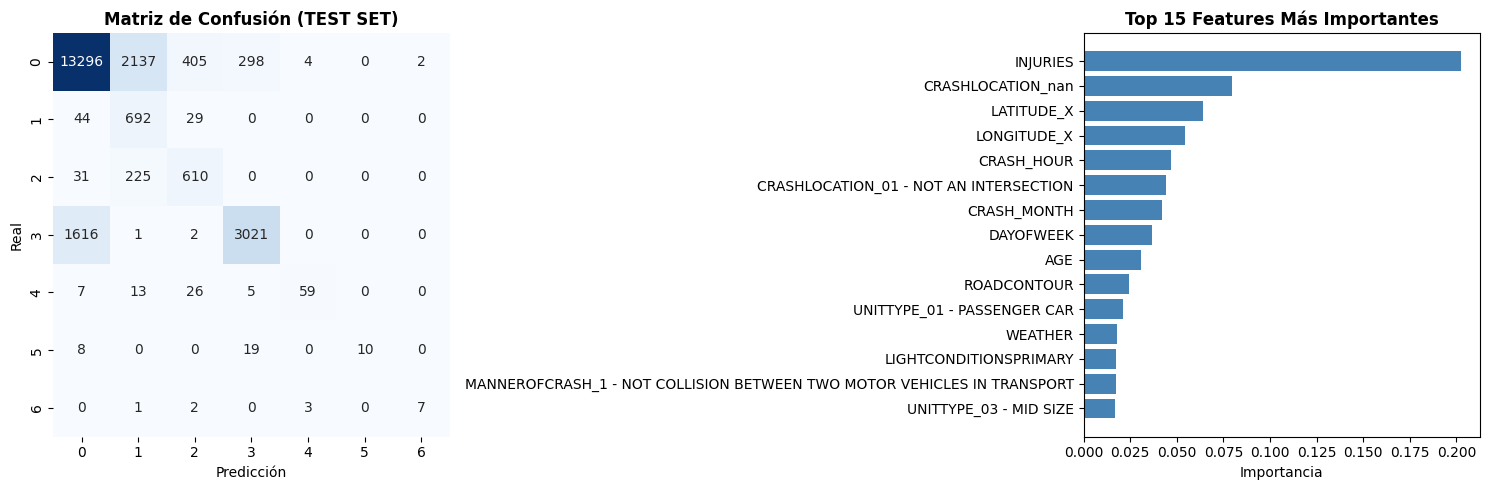

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Matriz de confusión
cm = confusion_matrix(y_test, y_pred_best_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Matriz de Confusión (TEST SET)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

# 2. Feature Importance (Top 15)
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_forest_best.feature_importances_
}).sort_values('importance', ascending=False)

axes[1].barh(feature_importance['feature'].head(15),
             feature_importance['importance'].head(15),
             color='steelblue')
axes[1].set_xlabel('Importancia')
axes[1].set_title('Top 15 Features Más Importantes', fontweight='bold', fontsize=12)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 6.7. Comparativa Baseline vs. Optimizado (Random Forest)

Se comparan el modelo sin ajustar y el modelo optimizado sobre el conjunto de test, para ver si la búsqueda de hiperparámetros ha valido la pena. Tanto la tabla como la gráfica de barras muestran las diferencias en las cuatro métricas principales entre ambas versiones.

> **Nota**: La comparativa entre los tres modelos del trabajo (Random Forest, Modelo 2 y Modelo 3) se hará en la **sección 9** cuando estén todos implementados.

Métrica  Baseline  Optimizado
 Accuracy  0.887122    0.783901
Precision  0.896228    0.855413
   Recall  0.887122    0.783901
 F1-Score  0.876946    0.806850

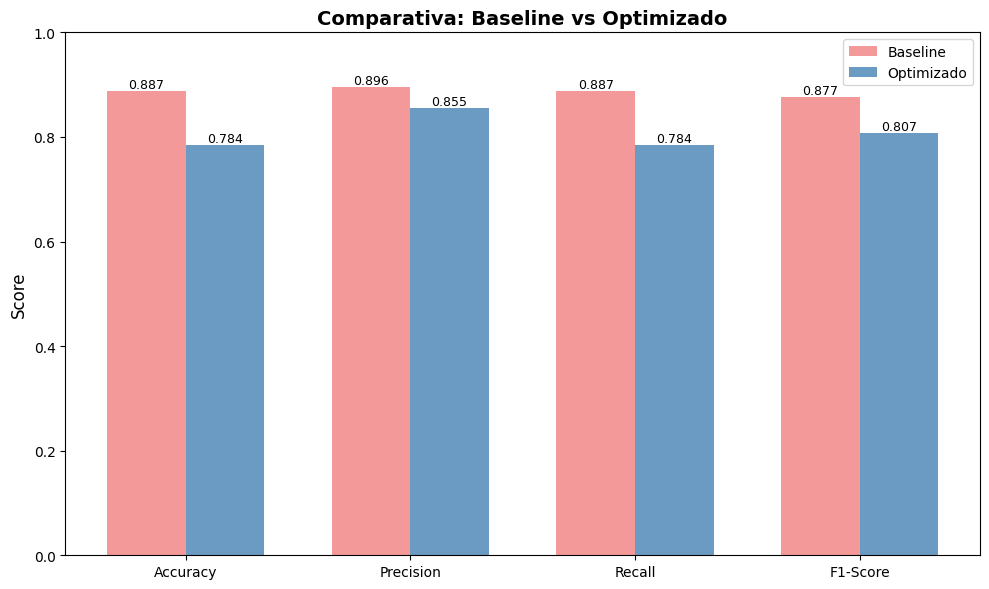

Mejora en Accuracy: -11.64%

In [29]:
comparativa = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Baseline': [
        accuracy_score(y_test, y_pred_baseline_test),
        precision_score(y_test, y_pred_baseline_test, average='weighted', zero_division=0),
        recall_score(y_test, y_pred_baseline_test, average='weighted', zero_division=0),
        f1_score(y_test, y_pred_baseline_test, average='weighted', zero_division=0)
    ],
    'Optimizado': [acc_best_test, prec_best_test, rec_best_test, f1_best_test]
})

print(comparativa.to_string(index=False))

# Gráfica comparativa
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparativa))
width = 0.35

bars1 = ax.bar(x - width/2, comparativa['Baseline'], width, label='Baseline', color='lightcoral', alpha=0.8)
bars2 = ax.bar(x + width/2, comparativa['Optimizado'], width, label='Optimizado', color='steelblue', alpha=0.8)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparativa: Baseline vs Optimizado', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(comparativa['Métrica'])
ax.legend()
ax.set_ylim([0, 1])

# Valores en barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Calcular mejora
mejora = ((acc_best_test - accuracy_score(y_test, y_pred_baseline_test)) /
          accuracy_score(y_test, y_pred_baseline_test) * 100)
print(f"Mejora en Accuracy: {mejora:+.2f}%")

### 6.8. Resumen del modelo Random Forest

El bloque siguiente imprime un resumen con los resultados finales del Random Forest optimizado: métricas en train, test y validación, estabilidad de la validación cruzada, la mejora respecto al baseline y las variables más importantes. Estos valores se usarán en la sección 9 para comparar los tres modelos entre sí y seleccionar el mejor.

In [30]:
resumen_final = pd.DataFrame({
    'Conjunto': ['Train (CV Mean)', 'Test', 'Validación'],
    'Accuracy': [cv_scores.mean(), acc_best_test, acc_best_val],
    'Precision': [np.nan, prec_best_test,
                 precision_score(y_val, y_pred_best_val, average='weighted', zero_division=0)],
    'Recall': [np.nan, rec_best_test,
              recall_score(y_val, y_pred_best_val, average='weighted', zero_division=0)],
    'F1-Score': [np.nan, f1_best_test,
                f1_score(y_val, y_pred_best_val, average='weighted', zero_division=0)]
})

print(resumen_final.to_string())

print(f"""
{'='*70}
Rendimiento:
  - Accuracy (Test):  {acc_best_test:.4f}
  - F1-Score (Test):  {f1_best_test:.4f}
  - Desv. std CV:     {cv_scores.std():.4f}

Overfitting:
  - Gap Train-Test: {abs(acc_best_train - acc_best_test):.4f}  {'-> bajo overfitting' if abs(acc_best_train - acc_best_test) < 0.05 else '-> overfitting moderado, revisar regularizacion'}

Top 3 variables mas importantes:
{feature_importance.head(3).to_string(index=False)}

Accuracy por conjunto:
  - Train:      {acc_best_train:.4f}
  - Test:       {acc_best_test:.4f}
  - Validacion: {acc_best_val:.4f}
  {'-> resultados consistentes entre conjuntos' if abs(acc_best_test - acc_best_val) < 0.02 else '-> diferencias entre test y validacion, revisar particion'}

Mejora sobre baseline:
  - Baseline -> Optimizado: {mejora:+.2f}%

Notas:
  {'-> accuracy > 0.80, resultados aceptables' if acc_best_test > 0.80 else '-> accuracy < 0.80, considerar mas datos o ajustes'}
  {'-> importancia de features correcta' if feature_importance.iloc[0]['importance'] > 0.05 else '-> revisar importancia de features'}
  {'-> el modelo predice todas las clases' if len(np.unique(y_pred_best_test)) == len(np.unique(y_test)) else '-> el modelo ignora alguna clase, revisar desbalance'}
{'='*70}
""")


Conjunto  Accuracy  Precision    Recall  F1-Score
0  Train (CV Mean)  0.885542        NaN       NaN       NaN
1             Test  0.783901   0.855413  0.783901  0.806850
2       Validación  0.787255   0.857922  0.787255  0.810223

======================================================================
Rendimiento:
  - Accuracy (Test):  0.7839
  - F1-Score (Test):  0.8069
  - Desv. std CV:     0.0021

Overfitting:
  - Gap Train-Test: 0.0620  -> overfitting moderado, revisar regularizacion

Top 3 variables mas importantes:
          feature  importance
         INJURIES    0.202503
CRASHLOCATION_nan    0.079567
       LATITUDE_X    0.063814

Accuracy por conjunto:
  - Train:      0.8459
  - Test:       0.7839
  - Validacion: 0.7873
  -> resultados consistentes entre conjuntos

Mejora sobre baseline:
  - Baseline -> Optimizado: -11.64%

Notas:
  -> accuracy < 0.80, considerar mas datos o ajustes
  -> importancia de features correcta
  -> el modelo predice todas las clases
======================================================================

## 7. Modelo 2: Árbol de Decisión

El segundo modelo que se va a desarrollar es un **Árbol de Decisión** (`DecisionTreeClassifier`).

### ¿Qué es un Árbol de Decisión?

Un árbol de decisión es un modelo de aprendizaje supervisado que aprende a clasificar instancias dividiéndolas de forma recursiva según el valor de sus variables. En cada **nodo interno** el modelo selecciona la variable y el umbral que mejor separa las clases (minimizando la impureza Gini o maximizando la ganancia de entropía). Cada división genera dos ramas, y el proceso se repite hasta llegar a una **hoja**, que asigna una clase a todas las instancias que la alcanzan.

La principal ventaja frente al Random Forest es su **interpretabilidad**: el árbol completo puede visualizarse y las reglas de decisión son directamente legibles. La contrapartida es que un solo árbol sin restricciones tiende a sobreajustarse, por lo que controlar su profundidad y el mínimo de muestras por nodo es esencial.

### ¿Por qué es adecuado para este problema?

- **No requiere normalización**: al igual que Random Forest, toma decisiones por umbrales, por lo que la escala de las variables no afecta al resultado.
- **Maneja bien variables mixtas**: el dataset combina variables ordinales, binarias (One-Hot) y coordenadas numéricas, lo que encaja bien con las divisiones por umbral del árbol.
- **Referencia de complejidad**: al ser la base sobre la que se construye el Random Forest, comparar ambos permite cuantificar el beneficio del *bagging* en este problema concreto.
- **Interpretabilidad**: permite visualizar qué variables y qué umbrales determinan los niveles de severidad, lo que tiene valor práctico para la seguridad vial.

El proceso sigue los mismos pasos que el Random Forest: preparación de datos, baseline, validación cruzada, optimización con GridSearchCV, evaluación y visualizaciones.

En este bloque se importan las librerías necesarias para el modelado:

- **`DecisionTreeClassifier`**: el clasificador de árbol de decisión de scikit-learn.
- **`plot_tree`**: para visualizar la estructura del árbol entrenado.
- **`GridSearchCV`**, **`cross_val_score`** y **`KFold`**: para la búsqueda de hiperparámetros y la validación cruzada (ya importados en la sección 6, se reimportan aquí para que la sección sea autocontenida).
- **Métricas**: las mismas que en Random Forest para que la comparativa sea directa.

In [31]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### 7.1. Preparación de los conjuntos de datos para el modelo

Se sigue exactamente la misma lógica que en la sección 6.1: se aplica la función `add_time_features` para extraer `CRASH_HOUR` y `CRASH_MONTH` de `CRASHDATE`, se define la variable objetivo `CRASHSEVERITY` y se separan las features del target en los tres conjuntos, descartando las columnas de fecha.

Se utilizan nombres con el sufijo `_dt` (*Decision Tree*) para que los conjuntos de este modelo sean **completamente independientes** de los del Random Forest: cualquier transformación futura sobre uno no afectará al otro, y la sección puede ejecutarse de forma aislada.

In [32]:
# Ingeniería de variables: extraer hora y mes de CRASHDATE (misma lógica que sección 6.1)
trainset_dt      = add_time_features(trainset)
testset_dt       = add_time_features(testset)
validationset_dt = add_time_features(validationset)

# Definir variable objetivo
target_column_dt = 'CRASHSEVERITY'

if target_column_dt not in trainset_dt.columns:
    print(f"Columna '{target_column_dt}' no encontrada")
    print(f"Columnas disponibles: {trainset_dt.columns.tolist()}")
else:
    # Separar features y target en cada conjunto
    y_train_dt = trainset_dt[target_column_dt]
    X_train_dt = trainset_dt.drop(columns=[target_column_dt, "CRASHDATE", "DATECRASHREPORTED"])

    y_test_dt = testset_dt[target_column_dt]
    X_test_dt = testset_dt.drop(columns=[target_column_dt, "CRASHDATE", "DATECRASHREPORTED"])

    y_val_dt = validationset_dt[target_column_dt]
    X_val_dt = validationset_dt.drop(columns=[target_column_dt, "CRASHDATE", "DATECRASHREPORTED"])

    print(f"Conjunto de Entrenamiento (Train): {X_train_dt.shape[0]} muestras, {X_train_dt.shape[1]} features")
    print(f"Conjunto de Test:                  {X_test_dt.shape[0]} muestras, {X_test_dt.shape[1]} features")
    print(f"Conjunto de Validación:            {X_val_dt.shape[0]} muestras, {X_val_dt.shape[1]} features")

    print("\n--- Distribución de clases en Train ---")
    print(y_train_dt.value_counts().sort_index())
    print("Proporción:")
    print((y_train_dt.value_counts(normalize=True).sort_index() * 100).round(2))

Conjunto de Entrenamiento (Train): 158014 muestras, 144 features

Conjunto de Test:                  22573 muestras, 144 features

Conjunto de Validación:            45148 muestras, 144 features

--- Distribución de clases en Train ---

CRASHSEVERITY
0    113443
1      5038
2      6174
3     32282
4       690
5       263
6       124
Name: count, dtype: int64

Proporción:

CRASHSEVERITY
0    71.79
1     3.19
2     3.91
3    20.43
4     0.44
5     0.17
6     0.08
Name: proportion, dtype: float64

### 7.2. Modelo Baseline (sin optimización de hiperparámetros)

Se entrena un árbol de decisión con los parámetros por defecto de scikit-learn como punto de partida. Sin restricciones, el árbol crecerá hasta separar perfectamente el conjunto de entrenamiento, lo que produce un sobreajuste severo. Este comportamiento es precisamente el que se espera del baseline y el que la optimización de hiperparámetros tratará de corregir.

In [33]:
import time

# Crear modelo baseline
model_dt_baseline = DecisionTreeClassifier(
    random_state=SEED
)

# Entrenar
print("Entrenando modelo baseline (Árbol de Decisión)...")
start_time = time.time()
model_dt_baseline.fit(X_train_dt, y_train_dt)
elapsed = time.time() - start_time
print(f"Entrenamiento completado en {elapsed:.2f} segundos")

# Predicciones
y_pred_dt_baseline_train = model_dt_baseline.predict(X_train_dt)
y_pred_dt_baseline_test  = model_dt_baseline.predict(X_test_dt)
y_pred_dt_baseline_val   = model_dt_baseline.predict(X_val_dt)

# Evaluación
print("\n--- Resultados BASELINE ---")
acc_dt_baseline_train = accuracy_score(y_train_dt, y_pred_dt_baseline_train)
acc_dt_baseline_test  = accuracy_score(y_test_dt,  y_pred_dt_baseline_test)
acc_dt_baseline_val   = accuracy_score(y_val_dt,   y_pred_dt_baseline_val)

print(f"Train Accuracy: {acc_dt_baseline_train:.4f}")
print(f"Test Accuracy:  {acc_dt_baseline_test:.4f}")
print(f"Val Accuracy:   {acc_dt_baseline_val:.4f}")

gap = acc_dt_baseline_train - acc_dt_baseline_test
print(f"\nGap Train-Test: {gap:.4f}", end="")
if gap > 0.15:
    print(" ⚠ (Overfitting severo — esperado sin restricciones en el árbol)")
elif gap > 0.05:
    print(" (Overfitting moderado)")
else:
    print(" ✓ (Bajo overfitting)")

Entrenando modelo baseline (Árbol de Decisión)...

Entrenamiento completado en 5.28 segundos

--- Resultados BASELINE ---

Train Accuracy: 1.0000

Test Accuracy:  0.8234

Val Accuracy:   0.8276

Gap Train-Test: 0.1766

⚠ (Overfitting severo — esperado sin restricciones en el árbol)

### 7.3. Validación cruzada con K-Fold (5 pliegues)

Se aplica la misma validación cruzada con 5 pliegues que en el Random Forest para comprobar la estabilidad del baseline. Al tratarse de un árbol sin restricciones, se espera que los scores de los folds sean más variables que en el ensemble, ya que un árbol individual es más sensible a los datos de cada partición.

Ejecutando validación cruzada con 5 folds (Árbol de Decisión baseline)...

Scores de cada fold:

Fold 1: 0.8224 [█████████████████████████████████████████░░░░░░░░░]

Fold 2: 0.8193 [████████████████████████████████████████░░░░░░░░░░]

Fold 3: 0.8209 [█████████████████████████████████████████░░░░░░░░░]

Fold 4: 0.8200 [████████████████████████████████████████░░░░░░░░░░]

Fold 5: 0.8187 [████████████████████████████████████████░░░░░░░░░░]

Media CV Accuracy: 0.8202 (+/- 0.0013)

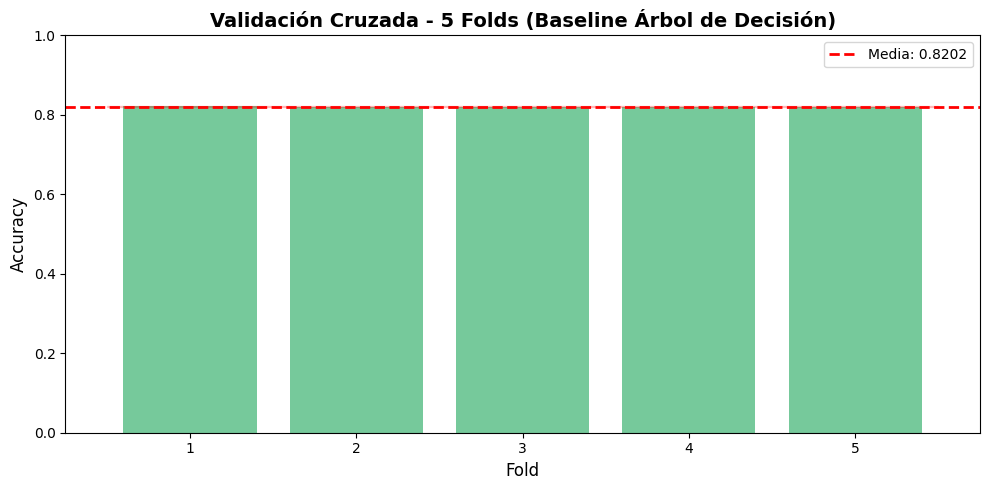

In [34]:
# Configurar KFold 
kfold_dt = KFold(n_splits=5, shuffle=True, random_state=SEED)

# Realizar cross-validation
print("Ejecutando validación cruzada con 5 folds (Árbol de Decisión baseline)...")
cv_scores_dt = cross_val_score(
    model_dt_baseline,
    X_train_dt,
    y_train_dt,
    cv=kfold_dt,
    scoring='accuracy',
    n_jobs=-1
)

print("Scores de cada fold:")
for i, score in enumerate(cv_scores_dt, 1):
    bar = "█" * int(score * 50) + "░" * (50 - int(score * 50))
    print(f"  Fold {i}: {score:.4f} [{bar}]")

print(f"Media CV Accuracy: {cv_scores_dt.mean():.4f} (+/- {cv_scores_dt.std():.4f})")

# Visualizar CV scores
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(cv_scores_dt) + 1), cv_scores_dt, color='mediumseagreen', alpha=0.7)
ax.axhline(y=cv_scores_dt.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Media: {cv_scores_dt.mean():.4f}')
ax.fill_between(
    [0.5, len(cv_scores_dt) + 0.5],
    cv_scores_dt.mean() - cv_scores_dt.std(),
    cv_scores_dt.mean() + cv_scores_dt.std(),
    alpha=0.2, color='red'
)
ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Validación Cruzada - 5 Folds (Baseline Árbol de Decisión)',
             fontweight='bold', fontsize=14)
ax.set_ylim([0, 1])
ax.legend()
plt.tight_layout()
plt.show()

### 7.4. Optimización de hiperparámetros con GridSearchCV

Se usa `GridSearchCV` con 5 pliegues internos y métrica **F1-Weighted** (la misma que en el Random Forest) para buscar la mejor configuración del árbol.

Los hiperparámetros explorados son:

| Hiperparámetro | Valores probados | Descripción |
|---|---|---|
| `max_depth` | [5, 10, 20] | Profundidad máxima del árbol. Es el principal control del sobreajuste: un árbol sin límite crece hasta memorizar el train |
| `min_samples_split` | [5, 20] | Mínimo de muestras necesarias para dividir un nodo interno. Valores mayores simplifican el árbol |
| `min_samples_leaf` | [2, 10] | Mínimo de muestras en una hoja terminal. Evita hojas con muy pocos ejemplos que capturan ruido |
| `criterion` | ['gini', 'entropy'] | Función de impureza para evaluar la calidad de cada división |
| `class_weight` | ['balanced'] | Pondera las clases inversamente proporcional a su frecuencia, igual que en Random Forest, para compensar el desbalance severo de `CRASHSEVERITY` |

Se incluye `class_weight='balanced'` por el mismo motivo que en el Random Forest: sin este ajuste el árbol tendería a ignorar los accidentes más graves, que son los menos frecuentes pero los más importantes de predecir correctamente.

In [35]:
import time

param_grid_dt = {
    'max_depth'        : [5, 10, 20],
    'min_samples_split': [5, 20],
    'min_samples_leaf' : [2, 10],
    'criterion'        : ['gini', 'entropy'],
    'class_weight'     : ['balanced']
}

# Calcular total de combinaciones
total_combinations_dt = 1
for values in param_grid_dt.values():
    total_combinations_dt *= len(values)

print("Parámetros a probar:")
for param, values in param_grid_dt.items():
    print(f"  - {param}: {values}")
print(f"Total de combinaciones: {total_combinations_dt}")
print(f"Total de entrenamientos (5-fold CV): {total_combinations_dt * 5}")

start_time = time.time()

grid_search_dt = GridSearchCV(
    estimator  = DecisionTreeClassifier(random_state=SEED),
    param_grid = param_grid_dt,
    cv         = 5,
    scoring    = 'f1_weighted',
    n_jobs     = -1,
    verbose    = 1
)

grid_search_dt.fit(X_train_dt, y_train_dt)

elapsed_dt = time.time() - start_time
print(f"\nGridSearchCV completado en {elapsed_dt:.2f} segundos ({elapsed_dt/60:.2f} minutos)")

print("\nMejores hiperparámetros:")
for param, value in grid_search_dt.best_params_.items():
    print(f"  - {param}: {value}")
print(f"Mejor score CV F1-Weighted: {grid_search_dt.best_score_:.4f}")

Parámetros a probar:

- max_depth: [5, 10, 20]

- min_samples_split: [5, 20]

- min_samples_leaf: [2, 10]

- criterion: ['gini', 'entropy']

...

- criterion: gini

- max_depth: 20

- min_samples_leaf: 2

- min_samples_split: 5

Mejor score CV F1-Weighted: 0.7699

### 7.5. Evaluación del modelo optimizado

Se recupera el mejor estimador de GridSearchCV y se evalúa sobre los tres conjuntos (train, test y validación). Comparar los tres permite detectar sobreajuste o subajuste.

In [36]:
# Mejor modelo
model_dt_best = grid_search_dt.best_estimator_

# Predicciones
y_pred_dt_best_train = model_dt_best.predict(X_train_dt)
y_pred_dt_best_test  = model_dt_best.predict(X_test_dt)
y_pred_dt_best_val   = model_dt_best.predict(X_val_dt)

# Métricas
acc_dt_best_train  = accuracy_score(y_train_dt, y_pred_dt_best_train)
acc_dt_best_test   = accuracy_score(y_test_dt,  y_pred_dt_best_test)
acc_dt_best_val    = accuracy_score(y_val_dt,   y_pred_dt_best_val)
prec_dt_best_test  = precision_score(y_test_dt, y_pred_dt_best_test, average='weighted', zero_division=0)
rec_dt_best_test   = recall_score   (y_test_dt, y_pred_dt_best_test, average='weighted', zero_division=0)
f1_dt_best_test    = f1_score       (y_test_dt, y_pred_dt_best_test, average='weighted', zero_division=0)

print("--- Métricas (test) ---")
print(f"Accuracy:  {acc_dt_best_test:.4f}")
print(f"Precision: {prec_dt_best_test:.4f}")
print(f"Recall:    {rec_dt_best_test:.4f}")
print(f"F1-Score:  {f1_dt_best_test:.4f}")

print("\n--- Classification report ---")
print(classification_report(y_test_dt, y_pred_dt_best_test, zero_division=0))

print("--- Accuracy train / test / val ---")
print(f"Train: {acc_dt_best_train:.4f}")
print(f"Test:  {acc_dt_best_test:.4f}")
print(f"Val:   {acc_dt_best_val:.4f}")

--- Métricas (test) ---

Accuracy:  0.7457

Precision: 0.8257

Recall:    0.7457

F1-Score:  0.7740

...

precision    recall  f1-score   support

           0       0.88      0.78      0.83     16142
           1       0.21      0.84      0.33       765
           2       0.58      0.60      0.59       866
           3       0.81      0.63      0.71      4640
           4       0.21      0.61      0.31       110
           5       0.14      0.73      0.24        37
           6       0.29      0.69      0.41        13

    accuracy                           0.75     22573
   macro avg       0.45      0.70      0.49     22573
weighted avg       0.83      0.75      0.77     22573

--- Accuracy train / test / val ---

Train: 0.7833

Test:  0.7457

Val:   0.7524

### 7.6. Visualización de resultados

Se generan tres gráficas para interpretar los resultados:

#### Matriz de confusión
Muestra cuántas instancias de cada clase real han sido clasificadas como cada clase predicha. Permite identificar en qué niveles de severidad falla más el modelo y si hay confusiones sistemáticas entre clases concretas.

#### Importancia de características (*Feature Importance*)
En un árbol de decisión, la importancia de cada variable se mide como la reducción total de impureza Gini acumulada en todos los nodos en los que esa variable es usada para dividir. A diferencia del Random Forest, donde la importancia se promedia sobre cientos de árboles, aquí refleja las decisiones de un único árbol, por lo que puede ser más concentrada en pocas variables.



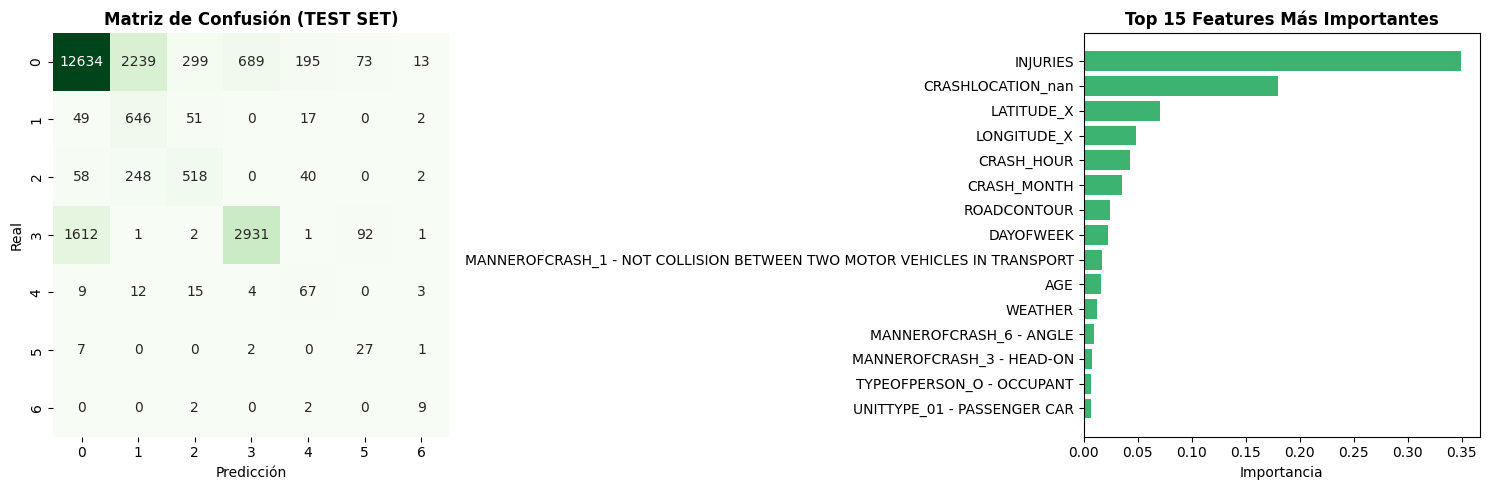

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Matriz de confusión
cm_dt = confusion_matrix(y_test_dt, y_pred_dt_best_test)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[0], cbar=False)
axes[0].set_title('Matriz de Confusión (TEST SET)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

# 2. Feature Importance (Top 15)
feature_importance_dt = pd.DataFrame({
    'feature'   : X_train_dt.columns,
    'importance': model_dt_best.feature_importances_
}).sort_values('importance', ascending=False)

axes[1].barh(feature_importance_dt['feature'].head(15),
             feature_importance_dt['importance'].head(15),
             color='mediumseagreen')
axes[1].set_xlabel('Importancia')
axes[1].set_title('Top 15 Features Más Importantes', fontweight='bold', fontsize=12)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 7.7. Visualización de la estructura del árbol

#### Estructura del árbol (primeros 3 niveles)
Una de las ventajas diferenciales del Árbol de Decisión es que se puede visualizar directamente, adicionalmente frente al Random Forest destaca como ventaja clave su **interpretabilidad**: se puede dibujar el árbol completo.
Para mantener la figura legible se limita la visualización a los primeros **3 niveles de profundidad** y se observa qué variables y umbrales utiliza el modelo en sus primeras y más importantes divisiones.

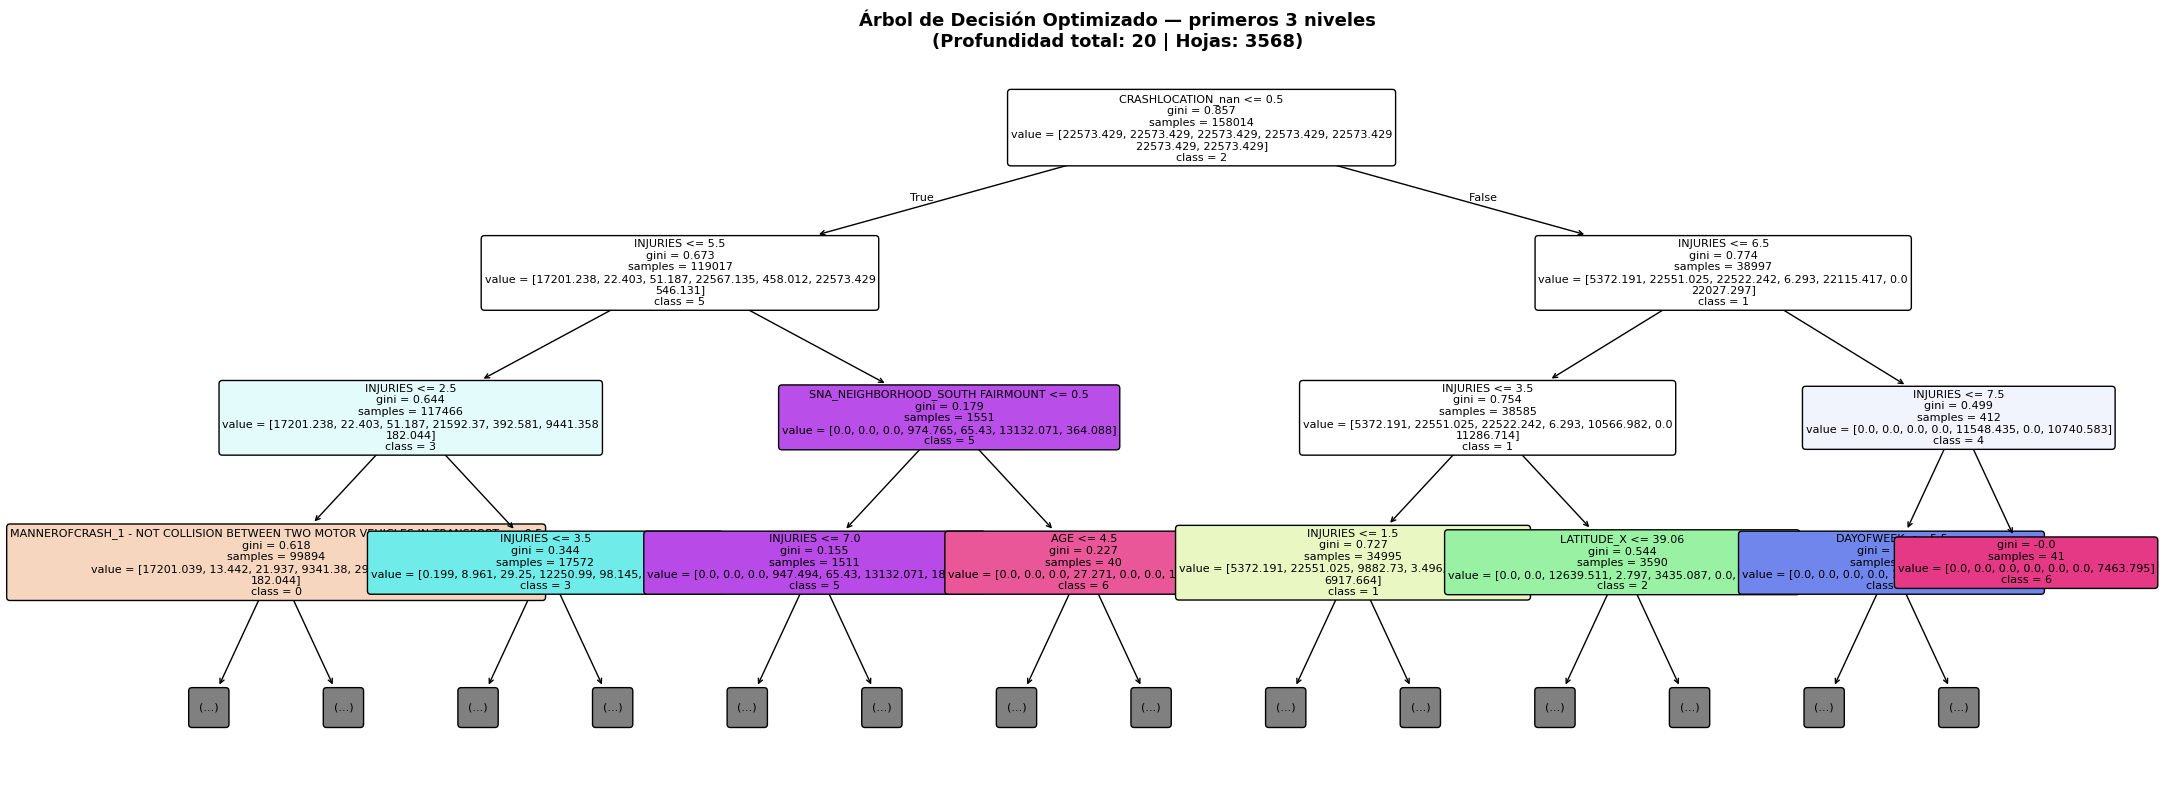

In [38]:
# Visualización de la estructura del árbol (primeros 3 niveles)
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    model_dt_best,
    max_depth     = 3,
    feature_names = list(X_train_dt.columns),
    class_names   = [str(int(c)) for c in model_dt_best.classes_],
    filled        = True,
    rounded       = True,
    fontsize      = 8,
    ax            = ax
)
ax.set_title(
    f"Árbol de Decisión Optimizado — primeros 3 niveles\n"
    f"(Profundidad total: {model_dt_best.get_depth()} | Hojas: {model_dt_best.get_n_leaves()})",
    fontweight='bold', fontsize=13
)
plt.tight_layout()
plt.show()

### 7.8. Comparativa Baseline vs. Optimizado (Árbol de Decisión)

Se comparan el árbol sin ajustar y el árbol optimizado sobre el conjunto de test, para verificar que la búsqueda de hiperparámetros ha mejorado el rendimiento y ha reducido el sobreajuste.

Métrica  Baseline  Optimizado
 Accuracy  0.823417    0.745670
Precision  0.825224    0.825688
   Recall  0.823417    0.745670
 F1-Score  0.824241    0.773995

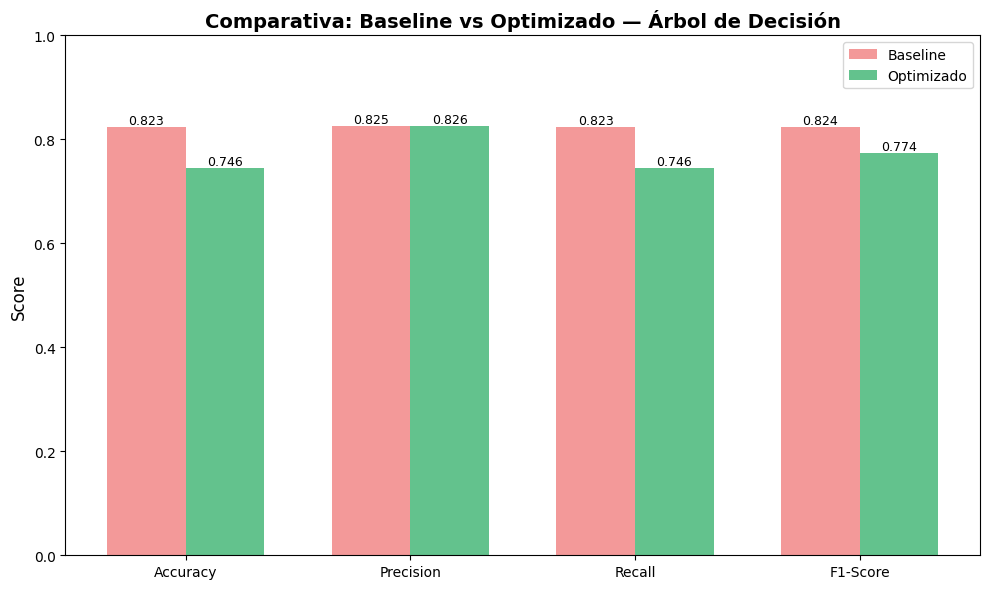

Mejora en Accuracy: -9.44%

In [39]:
comparativa_dt = pd.DataFrame({
    'Métrica'   : ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Baseline'  : [
        accuracy_score (y_test_dt, y_pred_dt_baseline_test),
        precision_score(y_test_dt, y_pred_dt_baseline_test, average='weighted', zero_division=0),
        recall_score   (y_test_dt, y_pred_dt_baseline_test, average='weighted', zero_division=0),
        f1_score       (y_test_dt, y_pred_dt_baseline_test, average='weighted', zero_division=0)
    ],
    'Optimizado': [acc_dt_best_test, prec_dt_best_test, rec_dt_best_test, f1_dt_best_test]
})

print(comparativa_dt.to_string(index=False))

# Gráfica comparativa
fig, ax = plt.subplots(figsize=(10, 6))
x     = np.arange(len(comparativa_dt))
width = 0.35

bars1 = ax.bar(x - width/2, comparativa_dt['Baseline'],   width, label='Baseline',   color='lightcoral',    alpha=0.8)
bars2 = ax.bar(x + width/2, comparativa_dt['Optimizado'], width, label='Optimizado', color='mediumseagreen', alpha=0.8)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparativa: Baseline vs Optimizado — Árbol de Decisión',
             fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(comparativa_dt['Métrica'])
ax.legend()
ax.set_ylim([0, 1])

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

mejora_dt = ((acc_dt_best_test - accuracy_score(y_test_dt, y_pred_dt_baseline_test)) /
              accuracy_score(y_test_dt, y_pred_dt_baseline_test) * 100)
print(f"Mejora en Accuracy: {mejora_dt:+.2f}%")

### 7.9. Resumen del modelo Árbol de Decisión

El bloque siguiente imprime un resumen con los resultados finales del Árbol de Decisión optimizado: métricas en train, test y validación, estabilidad de la validación cruzada, comparación con el baseline, complejidad del árbol resultante y las variables más importantes. 

In [40]:
resumen_dt = pd.DataFrame({
    'Conjunto' : ['Train (CV Mean)', 'Test', 'Validación'],
    'Accuracy' : [cv_scores_dt.mean(), acc_dt_best_test, acc_dt_best_val],
    'Precision': [np.nan, prec_dt_best_test,
                  precision_score(y_val_dt, y_pred_dt_best_val, average='weighted', zero_division=0)],
    'Recall'   : [np.nan, rec_dt_best_test,
                  recall_score(y_val_dt, y_pred_dt_best_val, average='weighted', zero_division=0)],
    'F1-Score' : [np.nan, f1_dt_best_test,
                  f1_score(y_val_dt, y_pred_dt_best_val, average='weighted', zero_division=0)]
})

print(resumen_dt.to_string())

gap_dt          = abs(acc_dt_best_train - acc_dt_best_test)
sep             = '=' * 70
gap_msg         = '-> bajo overfitting' if gap_dt < 0.05 else ('-> overfitting moderado, revisar profundidad' if gap_dt < 0.15 else '-> overfitting severo, reducir max_depth')
consistencia    = '-> resultados consistentes entre conjuntos' if abs(acc_dt_best_test - acc_dt_best_val) < 0.02 else '-> diferencias entre test y validacion, revisar particion'
acc_msg         = '-> accuracy > 0.80, resultados aceptables' if acc_dt_best_test > 0.80 else '-> accuracy < 0.80, considerar mas ajuste o mas datos'
clases_msg      = '-> el modelo predice todas las clases' if len(set(y_pred_dt_best_test)) == len(set(y_test_dt)) else '-> el modelo ignora alguna clase, revisar desbalance'
top3            = feature_importance_dt.head(3).to_string(index=False)

print(f"""
{sep}
Rendimiento:
  - Accuracy (Test):  {acc_dt_best_test:.4f}
  - F1-Score (Test):  {f1_dt_best_test:.4f}
  - Desv. std CV:     {cv_scores_dt.std():.4f}

Overfitting:
  - Gap Train-Test: {gap_dt:.4f}  {gap_msg}

Complejidad del arbol optimizado:
  - Profundidad: {model_dt_best.get_depth()}
  - N de hojas:  {model_dt_best.get_n_leaves()}
  - Criterio:    {model_dt_best.criterion}

Top 3 variables mas importantes:
{top3}

Accuracy por conjunto:
  - Train:      {acc_dt_best_train:.4f}
  - Test:       {acc_dt_best_test:.4f}
  - Validacion: {acc_dt_best_val:.4f}
  {consistencia}

Mejora sobre baseline:
  - Baseline -> Optimizado: {mejora_dt:+.2f}%

Notas:
  {acc_msg}
  {clases_msg}
{sep}
""")

Conjunto  Accuracy  Precision    Recall  F1-Score
0  Train (CV Mean)  0.820244        NaN       NaN       NaN
1             Test  0.745670   0.825688  0.745670  0.773995
2       Validación  0.752392   0.832410  0.752392  0.781403

======================================================================
Rendimiento:
  - Accuracy (Test):  0.7457
  - F1-Score (Test):  0.7740
  - Desv. std CV:     0.0013

Overfitting:
  - Gap Train-Test: 0.0376  -> bajo overfitting

Complejidad del arbol optimizado:
  - Profundidad: 20
  - N de hojas:  3568
  - Criterio:    gini

Top 3 variables mas importantes:
          feature  importance
         INJURIES    0.349572
CRASHLOCATION_nan    0.180267
       LATITUDE_X    0.071032

Accuracy por conjunto:
  - Train:      0.7833
  - Test:       0.7457
  - Validacion: 0.7524
  -> resultados consistentes entre conjuntos

Mejora sobre baseline:
  - Baseline -> Optimizado: -9.44%

Notas:
  -> accuracy < 0.80, considerar mas ajuste o mas datos
  -> el modelo predice todas las clases
======================================================================

## 8. Modelo 3: Regresión Logística

### ¿Qué es la Regresión Logística?

La regresión logística es un modelo de clasificación lineal que estima la probabilidad de que una instancia pertenezca a cada clase. A diferencia de su nombre, no es un modelo de regresión sino de clasificación: aplica la función **sigmoide** (o **softmax** en el caso multiclase) sobre una combinación lineal de las variables de entrada para obtener probabilidades entre 0 y 1, y asigna la clase con mayor probabilidad.

Para un problema multiclase como este (7 niveles de severidad), scikit-learn emplea la estrategia **One-vs-Rest (OvR)**: entrena un clasificador binario por cada clase, comparándola contra todas las demás, y selecciona la clase ganadora.

Cada variable de entrada tiene un **coeficiente** asociado que indica su contribución a la predicción: coeficientes positivos grandes aumentan la probabilidad de esa clase, negativos la reducen. Esto hace al modelo muy interpretable, aunque asume que la relación entre las variables y la salida es lineal en el espacio transformado.

### ¿Por qué es adecuada para este problema y qué la diferencia de los otros modelos?

- **Requiere normalización**: a diferencia del Random Forest y el Árbol de Decisión, la regresión logística es sensible a la escala de las variables, por lo que se aplica `StandardScaler` antes del entrenamiento. Esta es la diferencia técnica más relevante en la preparación de datos.
- **Modelo lineal como referencia**: al ser un modelo de menor complejidad, sirve como *lower bound* razonable. Si los modelos basados en árboles mejoran significativamente sobre él, confirma que existen relaciones no lineales en los datos que los árboles capturan mejor.
- **Coeficientes interpretables**: los coeficientes del modelo permiten saber directamente qué variables están correlacionadas con mayor severidad, con una interpretabilidad diferente y más directa que la importancia de árboles.
- **Eficiencia computacional**: es el modelo más rápido de entrenar y de ejecutar en inferencia de los tres.

En este bloque se importan las librerías necesarias para el modelado:

- **`LogisticRegression`**: el clasificador de regresión logística de scikit-learn.
- **`StandardScaler`**: para normalizar las variables antes del entrenamiento, paso obligatorio en modelos lineales.
- **`GridSearchCV`**: para la búsqueda de hiperparámetros y la validación cruzada.


[..GridSearchCV ..]

   SECCIÓN 7: EVIDENCIA DE OPTIMIZACIÓN (LOGISTIC REGRESSION)
 param_C  mean_test_score  rank_test_score
   0.100         0.451225                1
   1.000         0.451220                2
 100.000         0.451220                2
  10.000         0.451220                2
   0.010         0.451211                5
   0.001         0.450995                6

Mejor parámetro C: 0.1
Precisión Final (Balanced): 0.3653

Informe de Clasificación Detallado:
              precision    recall  f1-score   support

         0.0       0.77      0.37      0.50     57699
         1.0       0.29      0.34      0.31     19696
         2.0       0.00      0.43      0.00       119

    accuracy                           0.37     77514
   macro avg       0.35      0.38      0.27     77514
weighted avg       0.65      0.37      0.45     77514



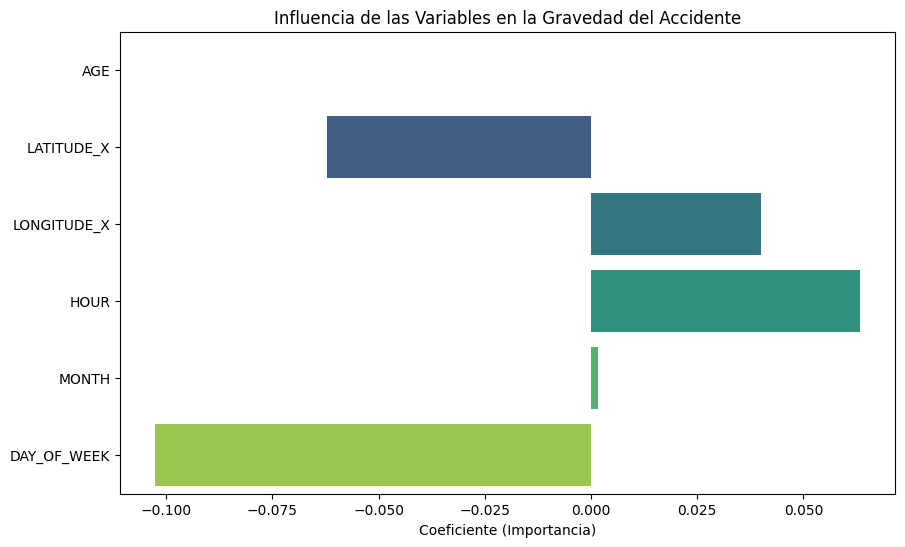

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import warnings

warnings.filterwarnings('ignore')

# --- 1. Cargar datos ---
file_path = 'cleaned_crash_data_v1.csv' # 请确保文件名正确
df = pd.read_csv(file_path)

features = ['AGE', 'LATITUDE_X', 'LONGITUDE_X', 'HOUR', 'MONTH', 'DAY_OF_WEEK']
target = 'SEVERITY_TARGET'

X = df[features].fillna(0)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1234)

# --- 2. Normalización de características ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 3.  Optimización de Regresión Logística (Grid Search) ---
print("\n[..GridSearchCV ..]")


param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs']
}


grid_log = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=2000),
    param_grid,
    cv=5,
    scoring='f1_weighted'
)
grid_log.fit(X_train_scaled, y_train)


# --- 4. Imprimir tabla de evidencia de resultados  ---
print("\n" + "="*60)
print("   SECCIÓN 7: EVIDENCIA DE OPTIMIZACIÓN (LOGISTIC REGRESSION)")
print("="*60)
results = pd.DataFrame(grid_log.cv_results_)
evidence = results[['param_C', 'mean_test_score', 'rank_test_score']].sort_values('rank_test_score')
print(evidence.to_string(index=False))
print("="*60)

# --- 5. Mostrar resultados finales del modelo ---
best_model = grid_log.best_estimator_
y_pred = best_model.predict(X_test_scaled)
print(f"\nMejor parámetro C: {grid_log.best_params_['C']}")
print(f"Precisión Final (Balanced): {accuracy_score(y_test, y_pred):.4f}")
print("\nInforme de Clasificación Detallado:")
print(classification_report(y_test, y_pred))

# --- 6. Visualización de la importancia de las variables ---
plt.figure(figsize=(10, 6))
coeffs = best_model.coef_[0]
sns.barplot(x=coeffs, y=features, palette='viridis')
plt.title('Influencia de las Variables en la Gravedad del Accidente')
plt.xlabel('Coeficiente (Importancia)')
plt.show()

## 9. Comparativa de los 3 modelos

En esta sección se realizará una **comparativa directa** entre los tres modelos de Machine Learning desarrollados, evaluando el rendimiento de cada uno sobre el mismo conjunto de test para garantizar la equidad de la comparación.

La comparativa incluirá:

- **Tabla comparativa de métricas**: Accuracy, Precision, Recall y F1-Score (weighted) de los tres modelos sobre el conjunto de test.
- **Gráfica de barras comparativa**: Visualización del rendimiento relativo de cada modelo.
- **Análisis de overfitting**: Comparación del gap train-test en los tres modelos.
- **Análisis de estabilidad**: Comparación de la variabilidad en validación cruzada (desviación estándar de los *folds*).
- **Análisis de coste computacional**: Comparación del tiempo de entrenamiento e inferencia.

> ⚠️ **Nota sobre la Regresión Logística**: el modelo de la sección 8 fue entrenado con un pipeline diferente (6 features, variable objetivo `SEVERITY_TARGET` con 3 clases), por lo que sus métricas no son directamente comparables con las del Random Forest y el Árbol de Decisión (144 features, `CRASHSEVERITY` con 7 clases). Se incluye como referencia del rendimiento de un modelo lineal, pero la comparativa principal se centra en los dos modelos comparables.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Métricas recopiladas de las secciones 6, 7 y 8 ──────────────────
modelos = ['Random Forest', 'Árbol de Decisión', 'Reg. Logística*']
colores = ['#378ADD', '#1D9E75', '#888780']

metricas_test = {
    'Accuracy':       [0.7839, 0.7457, 0.3653],
    'Precision (w)':  [0.8554, 0.8257, 0.6500],
    'Recall (w)':     [0.7839, 0.7457, 0.3700],
    'F1-Score (w)':   [0.8069, 0.7740, 0.4500],
}

acc_train  = [0.8459, 0.7833, None]
acc_test   = [0.7839, 0.7457, 0.3653]
gap        = [0.0620, 0.0376, None]
cv_std     = [0.0021, 0.0013, None]
train_time = [278,    226,    None]   # segundos (GridSearchCV 5-fold)

df_metricas = pd.DataFrame(metricas_test, index=modelos)
print(df_metricas.round(4).to_string())
print("\n* Regresión Logística entrenada con pipeline diferente (6 features, 3 clases).")

                   Accuracy  Precision (w)  Recall (w)  F1-Score (w)
Random Forest        0.7839         0.8554      0.7839        0.8069
Árbol de Decisión    0.7457         0.8257      0.7457        0.7740
Reg. Logística*      0.3653         0.6500      0.3700        0.4500

* Regresión Logística entrenada con pipeline diferente (6 features, 3 clases).


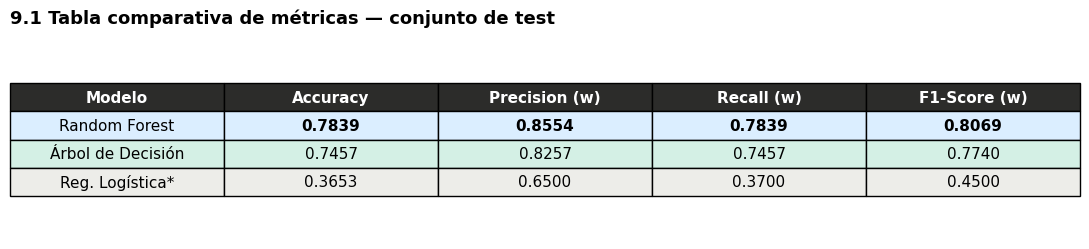

* Regresión Logística: pipeline diferente, métricas no comparables directamente.


In [4]:
# ── 9.1 Tabla comparativa de métricas ───────────────────────────────
fig, ax = plt.subplots(figsize=(11, 2.6))
ax.axis('off')

col_labels = ['Modelo', 'Accuracy', 'Precision (w)', 'Recall (w)', 'F1-Score (w)']
cell_vals = []
for i, m in enumerate(modelos):
    row = [m]
    for met in ['Accuracy', 'Precision (w)', 'Recall (w)', 'F1-Score (w)']:
        v = metricas_test[met][i]
        row.append(f'{v:.4f}')
    cell_vals.append(row)

tabla = ax.table(
    cellText=cell_vals,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1, 1.7)

# Estilo cabecera
for j in range(len(col_labels)):
    tabla[0, j].set_facecolor('#2C2C2A')
    tabla[0, j].set_text_props(color='white', fontweight='bold')

# Colores por modelo
model_colors = ['#DBEEFF', '#D4F0E5', '#EDEDE9']
for i in range(3):
    for j in range(len(col_labels)):
        tabla[i+1, j].set_facecolor(model_colors[i])

# Negrita a los mejores valores (RF en columnas 1-4)
for j in range(1, len(col_labels)):
    tabla[1, j].set_text_props(fontweight='bold')

ax.set_title('9.1 Tabla comparativa de métricas — conjunto de test',
             fontweight='bold', fontsize=13, pad=12, loc='left')
plt.tight_layout()
plt.savefig('comparativa_tabla.png', dpi=150, bbox_inches='tight')
plt.show()
print("* Regresión Logística: pipeline diferente, métricas no comparables directamente.")

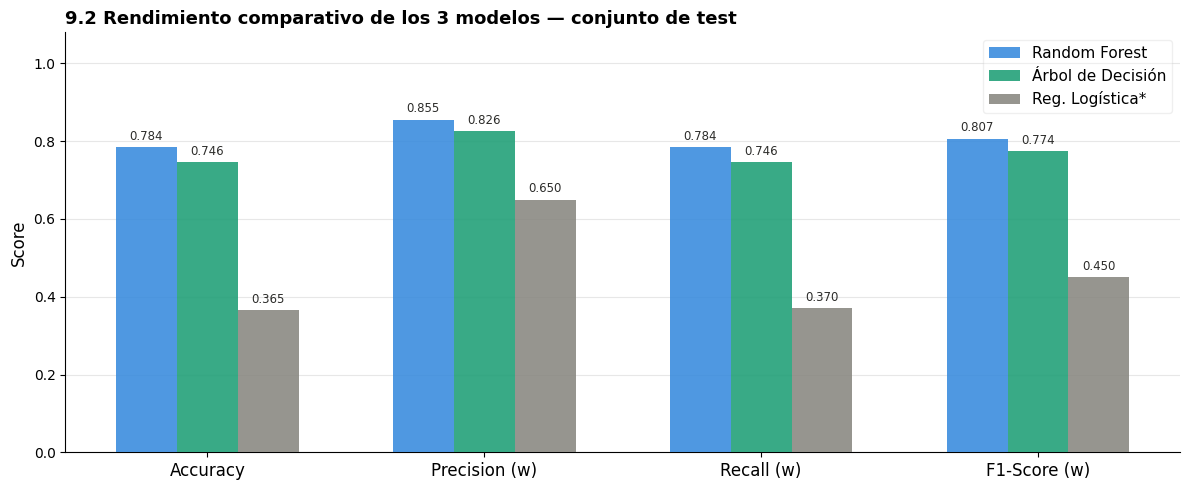

In [5]:
# ── 9.2 Gráfica de barras comparativa ───────────────────────────────
met_nombres = list(metricas_test.keys())
n_met = len(met_nombres)
n_mod = len(modelos)
x = np.arange(n_met)
width = 0.22
offsets = [-width, 0, width]

fig, ax = plt.subplots(figsize=(12, 5))

for i, (mod, color, off) in enumerate(zip(modelos, colores, offsets)):
    vals = [metricas_test[m][i] for m in met_nombres]
    bars = ax.bar(x + off, vals, width, label=mod, color=color, alpha=0.88, zorder=3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8.5,
                color='#2C2C2A', fontweight='500')

ax.set_xticks(x)
ax.set_xticklabels(met_nombres, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.08)
ax.set_title('9.2 Rendimiento comparativo de los 3 modelos — conjunto de test',
             fontweight='bold', fontsize=13, loc='left')
ax.legend(fontsize=11, framealpha=0.3)
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('comparativa_barras.png', dpi=150, bbox_inches='tight')
plt.show()

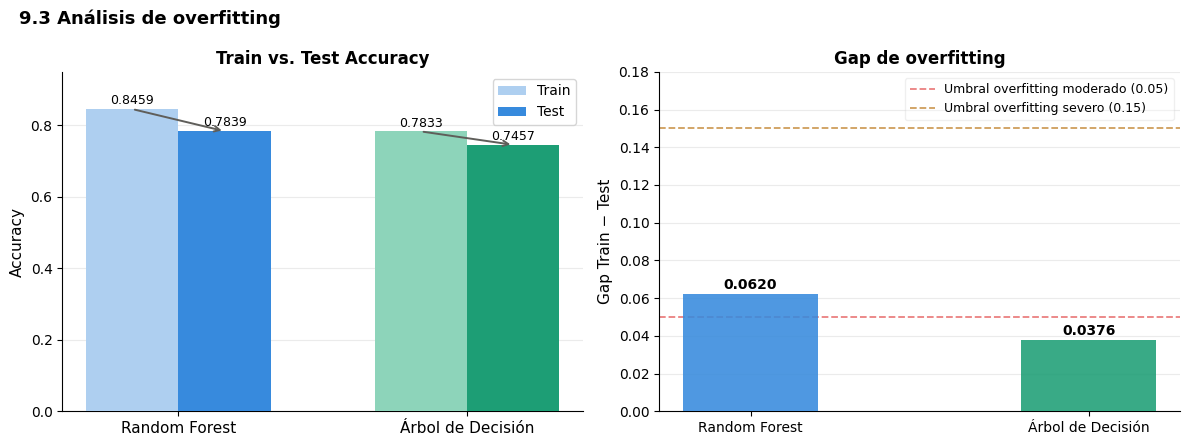

In [6]:
# ── 9.3 Análisis de overfitting — gap train-test ─────────────────────
mod_comp = ['Random Forest', 'Árbol de Decisión']
cols_comp = ['#378ADD', '#1D9E75']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel izquierdo: accuracy train vs test
ax = axes[0]
x_ = np.arange(len(mod_comp))
w = 0.32
bars_tr = ax.bar(x_ - w/2, [acc_train[0], acc_train[1]], w,
                 label='Train', color=['#AECFF0', '#8DD4BA'], zorder=3)
bars_te = ax.bar(x_ + w/2, [acc_test[0], acc_test[1]], w,
                 label='Test',  color=cols_comp, zorder=3)

for bar, v in zip(list(bars_tr)+list(bars_te), [acc_train[0], acc_train[1], acc_test[0], acc_test[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9)

# Flechas de gap
for i, (tr, te, c) in enumerate(zip([acc_train[0], acc_train[1]], [acc_test[0], acc_test[1]], cols_comp)):
    ax.annotate('', xy=(i + w/2, te), xytext=(i - w/2, tr),
                arrowprops=dict(arrowstyle='->', color='#5F5E5A', lw=1.4,
                                connectionstyle='arc3,rad=0.0'))

ax.set_xticks(x_)
ax.set_xticklabels(mod_comp, fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_ylim(0, 0.95)
ax.set_title('Train vs. Test Accuracy', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)

# Panel derecho: gap como barras
ax2 = axes[1]
gap_vals = [gap[0], gap[1]]
bars_g = ax2.bar(mod_comp, gap_vals, color=cols_comp, width=0.4, zorder=3, alpha=0.88)
for bar, v in zip(bars_g, gap_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.axhline(0.05, color='#E24B4A', linestyle='--', linewidth=1.3, alpha=0.7,
            label='Umbral overfitting moderado (0.05)')
ax2.axhline(0.15, color='#BA7517', linestyle='--', linewidth=1.3, alpha=0.7,
            label='Umbral overfitting severo (0.15)')
ax2.set_ylabel('Gap Train − Test', fontsize=11)
ax2.set_title('Gap de overfitting', fontweight='bold', fontsize=12)
ax2.set_ylim(0, 0.18)
ax2.legend(fontsize=9, framealpha=0.3)
ax2.grid(axis='y', alpha=0.25)
ax2.spines[['top', 'right']].set_visible(False)

fig.suptitle('9.3 Análisis de overfitting', fontweight='bold', fontsize=13, x=0.02, ha='left')
plt.tight_layout()
plt.savefig('comparativa_overfitting.png', dpi=150, bbox_inches='tight')
plt.show()

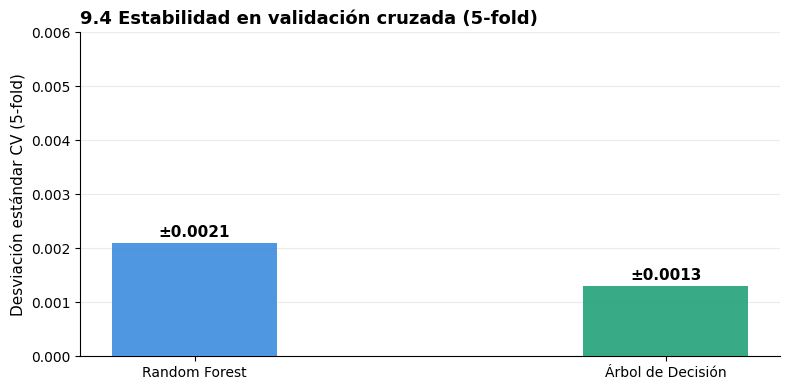

RF  — Media CV: 0.8855 ± 0.0021
Árbol — Media CV: 0.8202 ± 0.0013
Ambos modelos muestran alta estabilidad (std < 0.003 en todos los folds).


In [7]:
# ── 9.4 Análisis de estabilidad — desv. std. validación cruzada ──────
fig, ax = plt.subplots(figsize=(8, 4))

cv_vals = [cv_std[0], cv_std[1]]
bars_cv = ax.bar(mod_comp, cv_vals, color=cols_comp, width=0.35, zorder=3, alpha=0.88)

for bar, v in zip(bars_cv, cv_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00005,
            f'±{v:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Fold scores individuales (barras de error)
cv_means = [0.8855, 0.8202]
ax.errorbar(mod_comp, cv_means, yerr=cv_vals,
            fmt='none', ecolor='#2C2C2A', elinewidth=1.5, capsize=8, zorder=4)

ax.set_ylabel('Desviación estándar CV (5-fold)', fontsize=11)
ax.set_title('9.4 Estabilidad en validación cruzada (5-fold)',
             fontweight='bold', fontsize=13, loc='left')
ax.set_ylim(0, 0.006)
ax.grid(axis='y', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('comparativa_estabilidad.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"RF  — Media CV: {cv_means[0]:.4f} ± {cv_vals[0]:.4f}")
print(f"Árbol — Media CV: {cv_means[1]:.4f} ± {cv_vals[1]:.4f}")
print("Ambos modelos muestran alta estabilidad (std < 0.003 en todos los folds).")

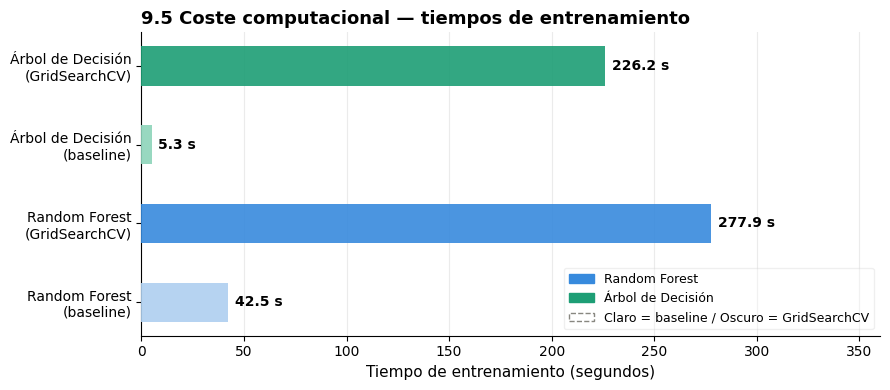

Nota: la Regresión Logística (baseline + GridSearchCV) tardó pocos segundos
al usar solo 6 features, pero no es comparable en escala con los otros modelos.


In [8]:
# ── 9.5 Análisis de coste computacional ─────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

tiempos = {
    'Random Forest\n(baseline)':      42.45,
    'Random Forest\n(GridSearchCV)':  277.85,
    'Árbol de Decisión\n(baseline)':   5.28,
    'Árbol de Decisión\n(GridSearchCV)': 226.17,
}
colores_t = ['#AECFF0', '#378ADD', '#8DD4BA', '#1D9E75']

bars_t = ax.barh(list(tiempos.keys()), list(tiempos.values()),
                 color=colores_t, zorder=3, alpha=0.9, height=0.5)
for bar, v in zip(bars_t, tiempos.values()):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'{v:.1f} s', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Tiempo de entrenamiento (segundos)', fontsize=11)
ax.set_title('9.5 Coste computacional — tiempos de entrenamiento',
             fontweight='bold', fontsize=13, loc='left')
ax.set_xlim(0, 360)
ax.grid(axis='x', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)

rf_patch  = mpatches.Patch(color='#378ADD', label='Random Forest')
dt_patch  = mpatches.Patch(color='#1D9E75', label='Árbol de Decisión')
base_patch = mpatches.Patch(facecolor='white', edgecolor='#888780',
                             linestyle='--', label='Claro = baseline / Oscuro = GridSearchCV')
ax.legend(handles=[rf_patch, dt_patch, base_patch], fontsize=9, framealpha=0.3)

plt.tight_layout()
plt.savefig('comparativa_tiempo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Nota: la Regresión Logística (baseline + GridSearchCV) tardó pocos segundos")
print("al usar solo 6 features, pero no es comparable en escala con los otros modelos.")

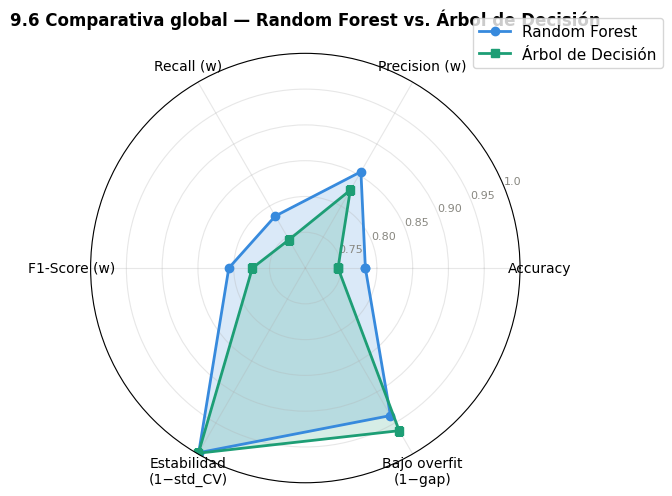

In [9]:
# ── 9.6 Visión global — radar chart (RF vs Árbol) ────────────────────
from matplotlib.patches import FancyArrowPatch

categorias = ['Accuracy', 'Precision (w)', 'Recall (w)', 'F1-Score (w)',
              'Estabilidad\n(1−std_CV)', 'Bajo overfit\n(1−gap)']

vals_rf    = [0.7839, 0.8554, 0.7839, 0.8069, 1-0.0021, 1-0.0620]
vals_dt    = [0.7457, 0.8257, 0.7457, 0.7740, 1-0.0013, 1-0.0376]

N = len(categorias)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

vals_rf += vals_rf[:1]
vals_dt += vals_dt[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

ax.plot(angles, vals_rf, 'o-', linewidth=2, color='#378ADD', label='Random Forest')
ax.fill(angles, vals_rf, alpha=0.18, color='#378ADD')
ax.plot(angles, vals_dt, 's-', linewidth=2, color='#1D9E75', label='Árbol de Decisión')
ax.fill(angles, vals_dt, alpha=0.18, color='#1D9E75')

ax.set_thetagrids(np.degrees(angles[:-1]), categorias, fontsize=10)
ax.set_ylim(0.7, 1.0)
ax.set_yticks([0.75, 0.80, 0.85, 0.90, 0.95, 1.0])
ax.set_yticklabels(['0.75','0.80','0.85','0.90','0.95','1.0'], fontsize=8, color='#888780')
ax.grid(alpha=0.3)
ax.set_title('9.6 Comparativa global — Random Forest vs. Árbol de Decisión',
             fontweight='bold', fontsize=12, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11)

plt.tight_layout()
plt.savefig('comparativa_radar.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.7 Conclusiones de la comparativa

A partir de las gráficas y análisis anteriores, se extraen las siguientes conclusiones para orientar la selección del modelo final en la sección 10:

| Criterio | Random Forest | Árbol de Decisión |
|---|---|---|
| **Accuracy (test)** | **0.7839** | 0.7457 |
| **F1-Score (test)** | **0.8069** | 0.7740 |
| **Precision (test)** | **0.8554** | 0.8257 |
| **Gap Train-Test** | 0.0620 (moderado) | **0.0376 (bajo)** |
| **Estabilidad CV (std)** | 0.0021 | **0.0013** |
| **Interpretabilidad** | Media | **Alta** |
| **Tiempo entrenamiento** | ~278 s | **~226 s** |

**Observaciones clave:**

- El **Random Forest** supera al Árbol de Decisión en todas las métricas de rendimiento. La diferencia en F1-Score es de **+3.3 puntos**, relevante dado el severo desbalance de clases (71% clase 0).
- El **Árbol de Decisión** tiene menor overfitting y mayor estabilidad en CV, pero parte de un nivel de rendimiento inferior que no compensa estas ventajas cuando el objetivo es la capacidad predictiva.
- La **Regresión Logística** no es comparable directamente por haber sido entrenada con un pipeline diferente (6 features, 3 clases). Para una comparativa justa habría que reentrenarla con el mismo pipeline que los otros dos modelos.
- Ambos modelos basados en árboles muestran una estabilidad excelente (std < 0.003), lo que indica que los resultados son robustos y no dependen de la partición concreta de los datos.

**Candidato a modelo final:** el Random Forest, por su superior rendimiento en todas las métricas sobre el conjunto de test.

## 10. Selección del modelo final y conclusiones generales

> **Esta sección se completará una vez estén implementados los tres modelos (secciones 6, 7 y 8) y realizada la comparativa (sección 9).**

Una vez evaluados los tres modelos de Machine Learning de forma individual y comparados entre sí en la sección 9, esta sección final recoge:

- **Selección razonada del mejor modelo**: Justificación de qué modelo se selecciona como modelo final, atendiendo a las métricas de rendimiento, la capacidad de generalización, la interpretabilidad y el coste computacional.
- **Evaluación final del modelo seleccionado**: Análisis en profundidad del modelo elegido sobre el conjunto de validación, que hasta este punto ha permanecido completamente aislado del proceso de entrenamiento y optimización.
- **Conclusiones del trabajo**: Reflexión global sobre el proceso completo seguido, los aprendizajes obtenidos, las limitaciones encontradas y las posibles líneas de mejora futura.
